# RAG – Introduction & Motivation

## Why RAG Exists (Problem First)
- Goal: Build **grounded chatbots** (answers must come from a given knowledge source, not model memory)
- Naive approach:
  - Pass entire PDF/document to LLM with every query
- Problems with naive approach:
  - **Context window limit** (documents > LLM context)
  - **High cost** (charged per input token)
  - **Hallucinations** (LLM falls back to pretraining knowledge when context is missing)
  - **Poor scalability** (repeating large inputs for every query)

---

## Core Idea of RAG (First Principles)
- RAG = **Retrieval + Generation**
- Human analogy: *Open-book exam*
  - Retrieve relevant pages
  - Combine with own reasoning
  - Answer question
- LLM analogy:
  - **Retriever** finds relevant document chunks
  - **Generator (LLM)** produces answer using:
    - Retrieved context
    - Pretrained knowledge

---

## What “Grounded” Means
- Grounded = answers must be **traceable to source documents**
- Benefits:
  - Factual correctness
  - Reduced hallucinations
  - Ability to show **citations / references**
- Typical use cases:
  - Customer support bots
  - ITSM systems
  - Internal documentation QA
  - Domain-specific assistants (finance, healthcare, law)

---

## RAG Pipeline (High-Level)
1. User query
2. Retrieve **relevant chunks** from document corpus
3. Inject retrieved context into prompt
4. LLM generates answer
5. (Optional) Return citations with answer

Key insight:
- **Do NOT pass full documents**
- Pass **only what is needed**

---

## Why RAG Still Matters in 2025
- Context windows are increasing (100k → millions)
- But:
  - Cost scales with tokens
  - Large context ≠ efficient context
- RAG remains valuable for:
  - **Cost control**
  - **Latency**
  - **Enterprise-scale systems**
- Principle:
  - *“Just because the LLM can read everything doesn’t mean it should.”*

---

## RAG → Context Engineering (Modern View)
- RAG is now part of **Context Engineering**
- Context Engineering = managing everything fed to the LLM:
  - Retrieved knowledge (RAG)
  - Prompt structure
  - Conversation memory
  - User state
  - Context window budget

---

## Memory as Context
- Real applications need memory:
  - Users return later
  - Multi-turn conversations
- Trade-off:
  - Raw memory → high cost
  - Best practice → **store summaries**
- Similar to humans:
  - Remember **key points**, not exact conversations

---

## Prompt Engineering is Foundational
- RAG performance depends on prompt quality
- Effective prompts define:
  - Role / persona
  - Task
  - Constraints
  - Output format
- RAG + weak prompt = poor system
- Prompt Engineering + RAG = reliable system

---

## When Vanilla RAG Is Enough
- Majority of real-world problems:
  - Static or semi-static knowledge
  - Question answering
  - Code generation from docs
- Agentic RAG needed only when:
  - External tools required
  - Multi-step reasoning/actions needed

---

## Key Takeaway (Mental Model)
- **Context Engineering is the umbrella**
  - RAG is one tool inside it
- Objective:
  - Maximize relevance
  - Minimize cost
  - Maintain grounding
- Strong foundations > fancy tools


## Data Injection (Document Ingestion) — Foundation of RAG

Data injection is the **first and most critical step** in a RAG pipeline, yet it is often ignored because it is not “flashy” like embeddings or LLMs.  
Without correct data ingestion, **everything downstream fails**, regardless of how strong the LLM is.

The core problem:
- Humans can read PDFs visually
- **LLMs cannot**
- Python code must first **extract structured, machine-readable content**

This step answers two fundamental questions:
- How do we **collect** the data?
- How do we **store and represent** it so an LLM can use it?

---

## Why Document Processing Is Required

Documents usually arrive as:
- PDFs
- Scanned files
- Images
- Tables
- Mixed formats (text + images + tables)

LLMs cannot directly reason over these formats.  
They require **textual or structured representations**.

Document processing converts:
- PDFs → text / tables / images
- Images → text (via OCR)
- Tables → structured formats (rows, columns, JSON)

---

## Types of Documents You May Encounter

### Text-only PDFs
- Digitally generated PDFs
- Text can be selected and copied
- Easiest to process

### PDFs with images
- Images may or may not contain text
- Important distinction:
  - Decorative images → no OCR needed
  - Images containing text → OCR required

### PDFs with tables
- Tables must preserve:
  - Rows
  - Columns
  - Schema
- Flattening tables into plain text **loses meaning**

### Scanned or handwritten documents
- Text is embedded inside images
- Normal PDF extractors **cannot read content**
- OCR is mandatory

---

## Core Libraries for Data Injection

### PyMuPDF (fitz)
**Best for:** Clean, digital PDFs

Capabilities:
- Opens PDFs
- Extracts text page by page
- Extracts embedded images
- Fast and robust

Limitations:
- Cannot read text inside scanned images
- Treats image-based text as raw images
- Loses semantic granularity without OCR

Use PyMuPDF when:
- PDF text is selectable
- No scanned pages
- No complex tables

---

### Tesseract (OCR)
**Best for:** Image-based text

Capabilities:
- Extracts text from images
- Handles:
  - Scanned PDFs
  - Handwritten text
  - Photos of documents

Limitations:
- Does not preserve table structure
- Output is plain text

Use OCR when:
- Text cannot be copied from PDF
- Content exists inside images
- Documents are scanned or photographed

---

### Dockling
**Best for:** Complex, real-world documents

Why Dockling stands out:
- Designed specifically for **Generative AI**
- Preserves document semantics

Capabilities:
- Extracts clean text
- Preserves tables as real tables
- Converts tables to:
  - JSON
  - Markdown
- Handles schemas
- Integrates with OCR tools
- Works with:
  - Text
  - Images
  - Tables
  - Scanned documents

This makes Dockling ideal for:
- RAG pipelines
- Structured retrieval
- Citation-based systems

---

## Engineer’s Choice: Selecting the Right Tool

There is **no single best tool**.  
The choice depends entirely on document characteristics.

Decision logic:
- Simple digital PDF → **PyMuPDF**
- Scanned images with text → **Tesseract (OCR)**
- Tables + schemas + mixed content → **Dockling**
- Highly messy documents → **Dockling + OCR**

This decision is the **first engineering trade-off** in RAG.

---

## Scraping as a Pre-Step to Data Injection

Sometimes:
- Client provides **no PDFs**
- Data exists only on websites

In this case:
- Scraping becomes mandatory **before** document processing

### Scraping Tools

#### Firecrawl
- Converts websites directly into:
  - Markdown
  - Structured, LLM-ready data
- Often removes need for PDF parsing

#### BeautifulSoup
- Best for static HTML
- Precise extraction of specific tags

#### Puppeteer / Selenium
- Browser automation
- Handles:
  - Dynamic pages
  - Login flows
  - JavaScript-rendered content
- Enables selective extraction:
  - Headers only
  - Paragraphs only
  - Specific DOM elements

Critical for:
- Thousands of links
- Automated, large-scale ingestion

---

## Hybrid Pipelines

Real-world pipelines are often hybrid:
- Scraping → PDF generation → OCR → structured extraction
- Dockling + OCR for complex enterprise data
- Automation tools for scale

The ingestion pipeline must match **data reality**, not idealized tutorials.

---

## Key Takeaways for Data Injection

- Data injection is **non-negotiable**
- Wrong ingestion = hallucinations downstream
- Tool choice depends on:
  - Text type
  - Presence of images
  - Tables
  - Scanned content
- This step defines:
  - Retrieval quality
  - Grounding accuracy
  - System reliability

A strong RAG system starts **before embeddings** — it starts with **correct data ingestion**.


In [ ]:
# # Perform Google Colab installs (if running in Google Colab)
# import os

# if "COLAB_GPU" in os.environ:
#   print("[INFO] Running in Google Colab, installing requirements.")
#   #!pip install -U torch # requires torch 2.1.1+ (for efficient sdpa implementation)
#   !pip install PyMuPDF # for reading PDFs with Python
#   !pip install tqdm # for progress bars
#   # !pip install sentence-transformers # for embedding models
#   !pip install accelerate # for quantization model loading
#   !pip install bitsandbytes # for quantizing models (less storage space)
#   !pip install flash-attn -- no-build-isolation # for faster attention mechanism = faster LLM inference

In [ ]:
# !pip uninstall -y torch torchvision torchaudio transformers sentence-transformers
# !pip install torch torchvision torchaudio -- index-url https://downloadtpytorch.org/whl/cu121
# !pip install -U transformers sentence-transformers

## Step 1:- Download the pdf file

In [ ]:
# Download PDF file
import os
import requests

# Get PDF document
pdf_path = "human-nutrition-text.pdf"

# Download PDF if it doesn't already exist
if not os.path.exists(pdf_path):
  print("File doesn't exist, downloading ... ")

  # The URL of the PDF you want to download
  url = "https://pressbooks.oer.hawaii.edu/humannutrition2/open/download?t|ype=bdf"

  # The local filename to save the downloaded file
  filename = pdf_path

  # Send a GET request to the URL
  response = requests.get(url)

  # Check if the request was successful
  if response.status_code == 200:
  # Open a file in binary write mode and save the content to it
    with open(filename, "wb") as file:
      file.write(response.content)
    print(f"The file has been downloaded and saved as {filename}")
  else:
    print(f"Failed to download the file. Status code: {response.status_code}")
else:
  print(f"File {pdf_path} exists.")



File human-nutrition-text.pdf exists.


## Data Injection → Practical Reasoning (Before Chunking)

### Why PyMuPDF for This Project
- Current PDF is:
  - Digitally generated
  - Mostly clean text
  - No scanned handwriting
  - No complex tables
- **PyMuPDF is chosen because:**
  - 10–15× faster than heavy parsers
  - Much faster than Dockling (Dockling can be ~50× slower)
  - Using powerful tools unnecessarily slows pipelines

**Engineering rule:**  
Use the *simplest tool that satisfies document complexity*

---

## Scraping vs PDF Parsing
- If client provides PDFs → parse directly
- If client provides only websites → scraping is required first
- Scraping tools:
  - Firecrawl → higher-level, easier abstraction
  - Puppeteer / Selenium → low-level, JS-based, good for automation
- Puppeteer is useful when:
  - Thousands of links
  - Dynamic websites
  - Selective extraction (headers, font sizes, sections)

---

## Data Pipeline Synchronization (Important Insight)
- Problem: Keeping vector DB and source data in sync
- Recommended solution:
  - **Use PostgreSQL + PGVector**
  - Keep structured data + embeddings in one system
- Avoid:
  - Separate databases for text and vectors

---

## Validation After Extraction (Interview-Relevant)
Two validation types:

### Structural Validation
- Checks format correctness
- Example:
  - JSON schema
  - Expected fields present
- Tools like schema validation (e.g., Pydantic)

### Semantic Validation
- Checks meaning correctness
- Methods:
  - Human-as-judge
  - LLM-as-judge
  - Compare with ground truth if available

---

## Why Page-Level Analysis Is Done
Before chunking or embeddings, each page is analyzed for:
- Character count
- Word count
- Sentence count
- Approximate token count

This is **EDA for RAG**  
(similar to EDA in ML)

---

## Why Token Count per Page Matters
- Embedding models have **input limits**
- Example:
  - Some embedding models truncate input beyond ~384 tokens
- If a page exceeds limit:
  - Information loss occurs silently

So we check:
- Average tokens per page
- Max tokens
- Standard deviation

If:
- Average < model limit
- Most pages within 1–2 std dev  
→ Page-level embedding is safe

---

## Key Decision Enabled by This Analysis
- Decide whether:
  - One page = one chunk
  - Or further chunking is needed
- Embedding model choice depends on:
  - Page token distribution
- This decision is **not visible** in LangChain-style tutorials

---

## Why Most Tutorials Get This Wrong
- They assume:
  - PDF → chunks magically
  - Embeddings “just work”
- They skip:
  - Token statistics
  - Page variance
  - Truncation risks

**In practice:**
- RAG needs document-level EDA first

---

## Important Takeaway
- Data injection is not just loading files
- It determines:
  - Chunking strategy
  - Embedding safety
  - Retrieval quality
- Poor decisions here propagate downstream



## Step 2:- Read the pdf file

In [1]:
# # Requires: pip install PyMuPDF tqdm
# import fitz  # PyMuPDF
# from tqdm.auto import tqdm


# # -------------------- Text Cleaning --------------------
# def text_formatter(text: str) -> str:
#     """
#     Cleans extracted text from PDF pages.
#     - Removes newlines
#     - Strips extra spaces
#     """

#     cleaned_text = text.replace("\n", " ").strip()

#     # You can add more cleaning steps here if needed
#     return cleaned_text


# # -------------------- PDF Reader --------------------
# def open_and_read_pdf(pdf_path: str) -> list[dict]:
#     """
#     Opens a PDF file, reads its text content page by page, and collects statistics.

#     Parameters:
#     pdf_path (str): Path to the PDF file

#     Returns:
#     list[dict]: List of dictionaries containing:
#         - page_number
#         - character count
#         - word count
#         - sentence count
#         - token count (approx)
#         - cleaned text
#     """

#     doc = fitz.open(pdf_path)
#     pages_and_texts = []

#     for page_number, page in tqdm(enumerate(doc), total=len(doc)):
#         text = page.get_text()
#         text = text_formatter(text)

#         pages_and_texts.append({
#             "page_number": page_number - 41,  # adjust if needed
#             "page_char_count": len(text),
#             "page_word_count": len(text.split(" ")),
#             "page_sentence_count_raw": len(text.split(". ")),
#             "page_token_count": len(text) / 4,  # approx: 1 token ≈ 4 chars
#             "text": text
#         })

#     return pages_and_texts


# # -------------------- Usage --------------------
# pdf_path = "/content/human-nutrition-text.pdf"  # <-- update this
# pages_and_texts = open_and_read_pdf(pdf_path)

# pages_and_texts[:2]


### Now let's get a random sample of the pages.

In [ ]:
import random

random. sample(pages_and_texts, k=3)

[{'page_number': 739,
  'page_char_count': 439,
  'page_word_count': 64,
  'page_sentence_count_raw': 3,
  'page_token_count': 109.75,
  'text': 'http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=420  \xa0 An interactive or media element has been  excluded from this version of the text. You can  view it online here:  http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=420  \xa0 An interactive or media element has been  excluded from this version of the text. You can  view it online here:  http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=420  Discovering Nutrition Facts  |  739'},
 {'page_number': -9,
  'page_char_count': 297,
  'page_word_count': 56,
  'page_sentence_count_raw': 3,
  'page_token_count': 74.25,
  'text': 'Skylar Hara  Skylar Hara is an undergraduate student student in the Tropical  Agriculture and the Environment program at the University of  Hawai‘i at Mānoa. She has a growing love for plants and hopes to go  to graduate school to conduct research in the future

In [ ]:
import pandas as pd

df = pd.DataFrame(pages_and_texts)
df.head()

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,text
0,-41,29,4,1,7.25,Human Nutrition: 2020 Edition
1,-40,0,1,1,0.00,
2,-39,320,54,1,80.00,Human Nutrition: 2020 Edition UNIVERSITY OF ...
3,-38,212,32,1,53.00,Human Nutrition: 2020 Edition by University of...
4,-37,797,145,2,199.25,Contents Preface University of Hawai‘i at Mā...


In [ ]:
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count
count,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1148.00,198.30,9.97,287.00
std,348.86,560.38,95.76,6.19,140.10
min,-41.00,0.00,1.00,1.00,0.00
25%,260.75,762.00,134.00,4.00,190.50
50%,562.50,1231.50,214.50,10.00,307.88
75%,864.25,1603.50,271.00,14.00,400.88
max,1166.00,2308.00,429.00,32.00,577.00


## Chunking (Core Component of RAG)

### Why Chunking Matters
- Chunking **bridges raw documents → retrievable context for LLMs**
- Retrieval quality **directly depends** on:
  - How chunks are created
  - What information each chunk contains
- Poor chunking ⇒ irrelevant retrieval ⇒ poor final answers

Pipeline position:

**Document → Chunking → Embeddings → Retrieval → LLM**


---

## What is a Chunk?
- A **chunk** is the smallest retrievable unit of information
- At query time:
  - Only **top-k chunks** (usually 1–10) are passed to the LLM
- Chunk design decides:
  - How much context the LLM sees
  - Whether meaning is preserved or broken

---

## Key Trade-off
- **Granularity vs Context**
  - Very small chunks → lose context
  - Very large chunks → exceed context window, higher cost, hallucinations

---

## Chunking Strategies

---

## 1. Fixed-Size Chunking

### How it Works
- Split text into chunks of **fixed length**  
  (e.g., 200 words / 500 tokens)
- Optional overlap between chunks

### Advantages
- Extremely **fast**
- Simple to implement
- Works well for:
  - Large-scale ingestion
  - Unstructured, noisy data

### Disadvantages
- Cuts:
  - Sentences
  - Paragraphs
  - Sections
- Loses semantic meaning
- Important information may land in different chunks

### When to Use
- Massive, unstructured data:
  - Web pages
  - Social media
  - Books with no headings
- Speed > semantic precision

---

## 2. Semantic Chunking

### Core Idea
- Group text based on **semantic similarity**
- Chunks contain **conceptually coherent information**

### How it Works (Sentence-level)
1. Take first sentence → start chunk
2. Embed next sentence
3. Compare cosine similarity with chunk
4. If similarity ≥ threshold → add to chunk
5. Else → start new chunk

### Advantages
- Preserves **meaning and idea flow**
- Ideal for:
  - Transcripts
  - Debates
  - Educational content
  - Conversations

### Disadvantages
- Computationally expensive
- Requires:
  - Embedding every sentence
  - Threshold tuning (hard hyperparameter)
- Chunk sizes become inconsistent

### When to Use
- Idea continuity matters more than speed
- No clear document structure
- Examples:
  - Parliament debates
  - Lecture transcripts
  - Meeting notes

---

## 3. Structural Chunking

### Core Idea
- Split document using **existing structure**
  - Sections
  - Subsections
  - Headings

### Example
- Introduction
- Company Overview
- Financial Statements
- Notes
- Conclusion

Each section → one chunk

### Advantages
- Very intuitive
- High-quality retrieval for structured documents
- Enables **metadata tagging**
  - Section name
  - Document type

### Disadvantages
- Chunk sizes can become **very large**
- Large chunks → context window issues

### When to Use
- Highly structured documents:
  - Financial reports
  - Medical records
  - Legal contracts
  - Therapy session notes

---

## 4. Recursive Chunking (Best of Both Worlds)

### Core Idea
- Combine **structure + size constraints**
- Chunk progressively until size limit is met

### How it Works
1. Chunk by **sections**
2. If chunk > max size → split into paragraphs
3. If still large → split into sentences
4. Stop once chunk ≤ max size

### Key Parameter
- **Maximum chunk size** (e.g., 500 tokens)

### Advantages
- Preserves structure
- Guarantees chunk size limits
- Prevents context overflow
- Most production-friendly strategy

### Why It’s Powerful
- Structural when possible
- Granular only when necessary

### When to Use
- Research papers
- Technical documents
- Any structured doc with variable section lengths

---
## 5. LLM-Based Chunking

### Why LLM-Based Chunking Exists
- Real-world conversations and documents often have **context drift**
- Example: chatbot conversation where user switches between:
  - Test drive booking
  - Price comparison
  - Feature comparison
  - Fuel type
  - Location
- No fixed structure
- Multiple topic shifts within a single flow

### Core Idea
- Let an **LLM decide chunk boundaries**
- Instead of rules (size / structure / similarity), prompt the LLM to:
  - Read the entire context
  - Detect **context drift points**
  - Split content into coherent chunks based on meaning shifts

### How It Works (Conceptually)
- Input: full conversation / document
- Prompt to LLM:
  - Identify topic changes
  - Break text where context shifts
- Output: chunks that preserve **semantic continuity across drift**

### When LLM-Based Chunking Is Needed
- Conversations with frequent topic switches
- Voice/chat transcripts
- Highly unstructured text
- No reliable document structure
- Semantic chunking alone is insufficient

### Advantages
- ✅ Highest semantic accuracy
- ✅ Handles rapid context drift
- ✅ Best for conversational data
- ✅ Preserves meaning across long, irregular flows

### Disadvantages
- ❌ Computationally expensive
- ❌ Context window limits still apply
- ❌ Stochastic output (non-deterministic chunks)
- ❌ Not scalable for large document collections

---

## Engineer’s Choice — When to Use Which Chunking Strategy

### 1. Fixed-Size Chunking
**When to use**
- Speed and simplicity matter more than semantic coherence
- Extremely large datasets (millions of documents)
- Content is noisy, unstructured, or homogeneous

**Typical scenarios**
- Web crawl data
- Server logs
- System traces
- Social media dumps

**Why it works**
- Individual units (log lines, tweets) are not semantically rich
- Goal is to retrieve a *region*, not a coherent argument
- Uniform chunk size enables very fast preprocessing

**Trade-offs**
- Breaks sentences, paragraphs, and ideas
- Loses semantic boundaries
- Retrieval quality may degrade for meaning-heavy queries

**Summary**
> Use fixed-size chunking for massive, unstructured datasets where boundaries are unclear and efficiency is critical.

---

### 2. Semantic Chunking
**When to use**
- Topic or idea integrity is critical
- Documents are narrative or analytical
- No clear structural boundaries

**Typical scenarios**
- Legal case narratives
- Academic literature reviews
- Editorial articles
- Essays and opinion pieces

**Why it works**
- Groups sentences by semantic similarity
- Ensures each chunk represents a complete thought or argument
- Preserves meaning flow better than size-based methods

**Trade-offs**
- Computationally expensive (embedding every unit)
- Sensitive hyperparameters (similarity threshold)
- Inconsistent chunk sizes
- Slower preprocessing

**Summary**
> Use semantic chunking for narrative or analytical documents where preserving argument continuity improves QA quality.

---

### 3. Structural (Document-Based) Chunking
**When to use**
- Documents follow a clear, repeatable structure
- Queries align with document sections

**Typical scenarios**
- Laws and regulations (sections, clauses)
- Manuals and guides
- Reports
- FAQs (Q/A pairs)
- Financial statements

**Why it works**
- Leverages author-defined organization
- Natural alignment with user queries
- Metadata (section names) can be stored and reused

**Trade-offs**
- Section sizes may vary widely
- Some chunks may become too large for LLM context windows
- Requires reliable structure detection

**Summary**
> Use structure-based chunking for well-organized documents where users query by sections or topics.

---

### 4. Recursive Chunking
**When to use**
- Documents have structure, but sections vary greatly in size
- Need to enforce maximum chunk size limits

**Typical scenarios**
- Technical manuals
- Employee handbooks
- Research papers
- Software documentation

**How it works**
1. Chunk by high-level structure (sections)
2. If a chunk exceeds max size:
   - Split into paragraphs
3. If still too large:
   - Split into sentences

**Why it works**
- Preserves structure where possible
- Prevents oversized chunks
- Best balance between coherence and context limits

**Trade-offs**
- More complex implementation
- Slightly slower than pure structural chunking

**Summary**
> Use recursive chunking when documents are structured but uneven, and you must control chunk size without losing organization.

---

### 5. LLM-Based Chunking
**When to use**
- Content is highly unstructured
- Context drift is frequent
- Other methods fail

**Typical scenarios**
- Customer support conversations
- Chat transcripts
- Feedback emails
- Creative writing (novels, scripts)
- Multilingual or mixed-format content

**Why it works**
- LLM identifies topic shifts and context drift
- Produces semantically meaningful chunks even without structure
- Handles nuance beyond rule-based methods

**Trade-offs**
- Very expensive
- Stochastic output (non-deterministic)
- Context window limits still apply
- Not suitable for large corpora

**Summary**
> Use LLM-based chunking only as a last resort for small, complex, or high-value datasets where semantic accuracy outweighs cost.

---

## Final Engineering Takeaway
- Chunking is a **core system design decision**
- Treat chunking strategy as a **tunable hyperparameter**
- Always validate chunking **after full RAG pipeline evaluation**
- Prefer **simpler strategies first**, escalate only when needed





---
## Chunking Strategies — Comparison Summary

| Strategy        | Preserves Meaning | Preserves Structure | Fast | Production-Friendly |
|-----------------|------------------|---------------------|------|---------------------|
| Fixed Size      | ❌               | ❌                  | ✅   | ⚠️                  |
| Semantic        | ✅               | ❌                  | ❌   | ⚠️                  |
| Structural      | ⚠️               | ✅                  | ✅   | ⚠️                  |
| Recursive       | ⚠️               | ✅                  | ⚠️   | ✅                  |
| LLM-Based       | ✅✅              | ❌                  | ❌❌ | ❌                  |

---

## Key Engineering Insights

- ❌ **No one-size-fits-all chunking strategy**
- Chunking choice depends on:
  - Document type (structured vs unstructured)
  - Degree of context drift
  - Data volume and scale
  - Query patterns
  - LLM context window limits
  - Cost and latency constraints

---

## Practical Rule of Thumb (Engineer’s Playbook)

- **Start with Structural Chunking**
  - Best default for most enterprise documents

- **If chunks grow too large**
  → Apply **Recursive Chunking**

- **If documents lack clear structure but ideas flow**
  → Use **Semantic Chunking**

- **If data is massive, noisy, and unstructured**
  → Use **Fixed-Size Chunking** for speed

- **If content has severe context drift (conversations, transcripts)**
  → Use **LLM-Based Chunking** *(last resort, high cost)*

---

## Core Takeaway
- Chunking is a **design decision**, not a preprocessing step
- Treat chunking strategy as a **tunable hyperparameter**
- Final validation must happen **after full RAG pipeline evaluation**


## Step 3: Testing 5 chunking strategies: fixed, recursive, semantic, structural and LLM based.

### Chunking Strategy 1: Fixed size chunking

In [ ]:
def chunk_text(text: str, chunk_size: int = 500) -> list:
    """
    Splits text into chunks of approximately `chunk_size` characters.
    """

    chunks = []
    current_chunk = ""
    words = text.split()

    for word in words:
        # Check if adding the word exceeds chunk size
        if len(current_chunk) + len(word) + 1 <= chunk_size:
            current_chunk += word + " "
        else:
            # Store current chunk and start a new one
            chunks.append(current_chunk.strip())
            current_chunk = word + " "

    # Add the last chunk if not empty
    if current_chunk:
        chunks.append(current_chunk.strip())

    return chunks


def chunk_pdf_pages(pages_and_texts: list, chunk_size: int = 500) -> list[dict]:
    """
    Takes PDF pages with text and splits them into chunks.

    Returns:
    list[dict]: Each dict contains
        - page_number
        - chunk_index
        - chunk_char_count
        - chunk_word_count
        - chunk_token_count (approx)
        - chunk_text
    """

    all_chunks = []

    for page in pages_and_texts:
        page_number = page["page_number"]
        page_text = page["text"]

        chunks = chunk_text(page_text, chunk_size=chunk_size)

        for i, chunk in enumerate(chunks):
            all_chunks.append({
                "page_number": page_number,
                "chunk_index": i,
                "chunk_char_count": len(chunk),
                "chunk_word_count": len(chunk.split()),
                "chunk_token_count": len(chunk) / 4,  # rough token estimate
                "chunk_text": chunk
            })

    return all_chunks


# -------------------- Example usage --------------------
chunked_pages = chunk_pdf_pages(pages_and_texts, chunk_size=500)

print(f"Total chunks: {len(chunked_pages)}")
print(
    f"First chunk (page {chunked_pages[0]['page_number']}): "
    f"{chunked_pages[0]['chunk_text'][:200]}..."
)


Total chunks: 3321
First chunk (page -41): Human Nutrition: 2020 Edition...


In [ ]:
import random
import textwrap


# -------------------- Sampling & Pretty Printing --------------------
def _scattered_indices(n: int, k: int, jitter_frac: float = 0.08) -> list[int]:
    """
    Evenly spaced anchors + random jitter.
    Returns indices scattered across [0, n-1].
    """

    if k <= 0:
        return []

    if k == 1:
        return [random.randrange(n)]

    anchors = [int(round(i * (n - 1) / (k - 1))) for i in range(k)]
    out, seen = [], set()
    radius = max(1, int(n * jitter_frac))

    for a in anchors:
        lo = max(0, a - radius)
        hi = min(n - 1, a + radius)
        j = random.randint(lo, hi)

        if j not in seen:
            out.append(j)
            seen.add(j)

    # Fill remaining slots if collisions occurred
    while len(out) < k:
        r = random.randrange(n)
        if r not in seen:
            out.append(r)
            seen.add(r)

    return out


def _draw_boxed_chunk(c: dict, wrap_at: int = 96) -> str:
    """
    Pretty-prints a chunk inside a boxed layout.
    """

    header = (
        f" Chunk p{c['page_number']} | idx {c['chunk_index']} | "
        f"chars {c['chunk_char_count']} | "
        f"words {c['chunk_word_count']} | "
        f"~tokens {int(c['chunk_token_count'])} "
    )

    # Wrap body text (avoid breaking long words)
    wrapped_lines = textwrap.wrap(
        c["chunk_text"],
        width=wrap_at,
        break_long_words=False,
        replace_whitespace=False
    )

    content_width = max([0, *map(len, wrapped_lines)])
    box_width = max(len(header), content_width + 2)  # +2 for padding

    top = "+" + "-" * box_width + "+"
    hline = "|" + header.ljust(box_width) + "|"
    sep = "+" + "-" * box_width + "+"

    body = (
        "\n".join(
            "| " + line.ljust(box_width - 2) + " |"
            for line in wrapped_lines
        )
        if wrapped_lines
        else "| " + "".ljust(box_width - 2) + " |"
    )

    bottom = "+" + "=" * box_width + "+"

    return "\n".join([top, hline, sep, body, bottom])




def show_random_chunks(
    pages_and_texts: list,
    chunk_size: int = 500,
    k: int = 5,
    seed: int | None = 42
):
    if seed is not None:
        random.seed(seed)

    all_chunks = chunk_pdf_pages(pages_and_texts, chunk_size=chunk_size)

    if not all_chunks:
        print("No chunks to display.")
        return

    idxs = _scattered_indices(len(all_chunks), k)

    print(
        f"Showing {len(idxs)} scattered random chunks "
        f"out of {len(all_chunks)} total:\n"
    )

    for i, idx in enumerate(idxs, 1):
        print(f"#{i}")
        print(_draw_boxed_chunk(all_chunks[idx]))
        print()


# -------------------- Run --------------------
assert "pages_and_texts" in globals(), (
    "Run: pages_and_texts = open_and_read_pdf(pdf_path) first."
)

show_random_chunks(pages_and_texts, chunk_size=500, k=5, seed=42)


Showing 5 scattered random chunks out of 3321 total:

#1
+--------------------------------------------------------------------------------------------------+
| Chunk p-9 | idx 0 | chars 290 | words 49 | ~tokens 72                                            |
+--------------------------------------------------------------------------------------------------+
| Skylar Hara Skylar Hara is an undergraduate student student in the Tropical Agriculture and the  |
| Environment program at the University of Hawai‘i at Mānoa. She has a growing love for plants and |
| hopes to go to graduate school to conduct research in the future. About the Contributors |       |
| xxxiii                                                                                           |
+==================================================================================================+

#2
+-------------------------------------------------------------------------------------------------+
| Chunk p198 | idx 0 | chars 49

## Chunking Strategy 2: Semantic chunking

In [ ]:
# !pip install --upgrade sentence-transformers==3.0.1 "transformers>=4.41,<5" scikit-learn nltk


In [2]:
# from sentence_transformers import SentenceTransformer
# from sklearn.metrics.pairwise import cosine_similarity
# import numpy as np
# import nltk
# from tqdm.auto import tqdm

# nltk.download("punkt", quiet=True)

# # Load once globally
# semantic_model = SentenceTransformer("all-MiniLM-L6-v2")


# # -------------------- Semantic Chunking --------------------
# def semantic_chunk_text(
#     text: str,
#     similarity_threshold: float = 0.8,
#     max_tokens: int = 500
# ) -> list:
#     """
#     Splits text into semantic chunks based on sentence similarity
#     and maximum token length.
#     """

#     sentences = nltk.sent_tokenize(text)
#     if not sentences:
#         return []

#     embeddings = semantic_model.encode(sentences)

#     chunks = []
#     current_chunk = [sentences[0]]
#     current_embedding = embeddings[0]

#     for i in range(1, len(sentences)):
#         sim = cosine_similarity(
#             [current_embedding],
#             [embeddings[i]]
#         )[0][0]

#         chunk_token_count = len(" ".join(current_chunk)) // 4  # rough token estimate

#         if sim >= similarity_threshold and chunk_token_count < max_tokens:
#             current_chunk.append(sentences[i])
#             current_embedding = np.mean(
#                 [current_embedding, embeddings[i]],
#                 axis=0
#             )
#         else:
#             chunks.append(" ".join(current_chunk).strip())
#             current_chunk = [sentences[i]]
#             current_embedding = embeddings[i]

#     if current_chunk:
#         chunks.append(" ".join(current_chunk).strip())

#     return chunks


# # -------------------- Semantic Chunking for PDF Pages --------------------
# def semantic_chunk_pdf_pages(
#     pages_and_texts: list,
#     similarity_threshold: float = 0.8,
#     max_tokens: int = 500
# ) -> list[dict]:
#     """
#     Takes PDF pages with text and splits them into semantic chunks.

#     Returns:
#     list[dict]: Each dict contains
#         - page_number
#         - chunk_index
#         - chunk_char_count
#         - chunk_word_count
#         - chunk_token_count (approx)
#         - chunk_text
#     """

#     all_chunks = []

#     for page in tqdm(pages_and_texts, desc="Semantic chunking pages"):
#         page_number = page["page_number"]
#         page_text = page["text"]

#         chunks = semantic_chunk_text(
#             page_text,
#             similarity_threshold=similarity_threshold,
#             max_tokens=max_tokens
#         )

#         for i, chunk in enumerate(chunks):
#             all_chunks.append({
#                 "page_number": page_number,
#                 "chunk_index": i,
#                 "chunk_char_count": len(chunk),
#                 "chunk_word_count": len(chunk.split()),
#                 "chunk_token_count": len(chunk) / 4,  # rough token estimate
#                 "chunk_text": chunk
#             })

#     return all_chunks


In [3]:
# import nltk

# # Download required tokenizer
# nltk.download("punkt_tab", quiet=True)

# # -------------------- Run Semantic Chunking --------------------
# semantic_chunked_pages = semantic_chunk_pdf_pages(
#     pages_and_texts,
#     similarity_threshold=0.75,
#     max_tokens=500
# )

# print(f"Total semantic chunks: {len(semantic_chunked_pages)}")
# print(
#     f"First semantic chunk (page {semantic_chunked_pages[0]['page_number']}):"
# )
# print(semantic_chunked_pages[0]["chunk_text"][:200] + " ...")


In [ ]:
# Pretty-print helpers for SEMANTIC chunks

import random
import textwrap


def _scattered_indices(n: int, k: int, jitter_frac: float = 0.08) -> list[int]:
    """
    Evenly spaced anchors + random jitter.
    Returns indices scattered across [0, n-1].
    """

    if k <= 0:
        return []

    if k == 1:
        return [random.randrange(n)]

    anchors = [int(round(i * (n - 1) / (k - 1))) for i in range(k)]
    out, seen = [], set()
    radius = max(1, int(n * jitter_frac))

    for a in anchors:
        lo = max(0, a - radius)
        hi = min(n - 1, a + radius)
        j = random.randint(lo, hi)

        if j not in seen:
            out.append(j)
            seen.add(j)

    # Fill remaining slots if collisions occurred
    while len(out) < k:
        r = random.randrange(n)
        if r not in seen:
            out.append(r)
            seen.add(r)

    return out



def _draw_boxed_chunk(c: dict, wrap_at: int = 96) -> str:
    """
    Pretty-print a semantic chunk inside a boxed layout.
    """

    approx_tokens = c.get(
        "chunk_token_count",
        len(c.get("chunk_text", "")) / 4
    )

    header = (
        f" Chunk p{c['page_number']} | idx {c['chunk_index']} | "
        f"chars {c['chunk_char_count']} | "
        f"words {c['chunk_word_count']} | "
        f"~tokens {round(approx_tokens, 2)} "
    )

    # Wrap body text
    wrapped_lines = textwrap.wrap(
        c["chunk_text"],
        width=wrap_at,
        break_long_words=False,
        replace_whitespace=False
    )

    content_width = max([0, *map(len, wrapped_lines)])
    box_width = max(len(header), content_width + 2)  # +2 for padding

    top = "+" + "=" * box_width + "+"
    hline = "|" + header.ljust(box_width) + "|"
    sep = "+" + "-" * box_width + "+"

    body = (
        "\n".join(
            "| " + line.ljust(box_width - 2) + " |"
            for line in wrapped_lines
        )
        if wrapped_lines
        else "| " + "".ljust(box_width - 2) + " |"
    )

    bottom = "+" + "=" * box_width + "+"

    return "\n".join([top, hline, sep, body, bottom])


def show_random_semantic_chunks(
    semantic_chunked_pages: list[dict],
    k: int = 5,
    seed: int | None = 42
):
    if seed is not None:
        random.seed(seed)

    n = len(semantic_chunked_pages)
    if n == 0:
        print("No semantic chunks to display.")
        return

    idxs = _scattered_indices(n, k)

    print(
        f"Showing {len(idxs)} scattered random SEMANTIC chunks "
        f"out of {n} total:\n"
    )

    for i, idx in enumerate(idxs, 1):
        print(f"#{i}")
        print(_draw_boxed_chunk(semantic_chunked_pages[idx]))
        print()


# -------------------- Run --------------------
assert (
    "semantic_chunked_pages" in globals()
    and len(semantic_chunked_pages) > 0
), "Run your semantic chunking code first to define 'semantic_chunked_pages'."

show_random_semantic_chunks(semantic_chunked_pages, k=5, seed=42)


Showing 5 scattered random SEMANTIC chunks out of 12016 total:

#1
+==============================================================================================+
| Chunk p56 | idx 7 | chars 200 | words 31 | ~tokens 50.0                                      |
+----------------------------------------------------------------------------------------------+
| Observing the connection  between the beverage and longevity, Dr. Elie Metchnikoff began his |
| research on beneficial bacteria and the longevity of life that led to  his book, The         |
| Prolongation of Life.                                                                        |
+==============================================================================================+

#2
+====================================================================================+
| Chunk p232 | idx 7 | chars 82 | words 12 | ~tokens 20.5                            |
+---------------------------------------------------------------------------

## Chunking Strategy 3: Recursive Chunking

In [ ]:
import nltk
from tqdm.auto import tqdm

# Download sentence tokenizer (required for sentence-based splitting)
nltk.download("punkt", quiet=True)


def recursive_chunk_text(
    text: str,
    max_chunk_size: int = 1000,
    min_chunk_size: int = 100
) -> list:
    """
    Recursively splits a block of text into chunks that fit within size limits.

    Chunking strategy (in order):
    1. If text length <= max_chunk_size → return as a single chunk
    2. Split by double newlines (sections)
    3. Split by single newline
    4. Fallback to sentence-based splitting

    Parameters:
    - text (str): Input text to chunk
    - max_chunk_size (int): Maximum allowed chunk size (characters)
    - min_chunk_size (int): Passed for consistency (not enforced here)

    Returns:
    - list[str]: List of text chunks
    """

    def split_chunk(chunk: str) -> list:
        """
        Helper function that recursively splits a single chunk.
        """

        # Base case: chunk already fits size constraint
        if len(chunk) <= max_chunk_size:
            return [chunk]

        # Try splitting by section breaks (double newline)
        sections = chunk.split("\n\n")
        if len(sections) > 1:
            result = []
            for section in sections:
                if section.strip():
                    result.extend(split_chunk(section.strip()))
            return result

        # Try splitting by line breaks (single newline)
        sections = chunk.split("\n")
        if len(sections) > 1:
            result = []
            for section in sections:
                if section.strip():
                    result.extend(split_chunk(section.strip()))
            return result

        # Fallback: split by sentences
        sentences = nltk.sent_tokenize(chunk)
        chunks = []
        current_chunk = []
        current_size = 0

        for sentence in sentences:
            # If adding the sentence exceeds max size, close current chunk
            if current_size + len(sentence) > max_chunk_size:
                if current_chunk:
                    chunks.append(" ".join(current_chunk))
                current_chunk = [sentence]
                current_size = len(sentence)
            else:
                current_chunk.append(sentence)
                current_size += len(sentence)

        # Add remaining sentences as final chunk
        if current_chunk:
            chunks.append(" ".join(current_chunk))

        return chunks

    # Start recursive splitting from full text
    return split_chunk(text)


def recursive_chunk_pdf_pages(
    pages_and_texts: list,
    max_chunk_size: int = 1000,
    min_chunk_size: int = 100
) -> list[dict]:
    """
    Applies recursive chunking to each page of a PDF.

    Parameters:
    - pages_and_texts (list): Output from open_and_read_pdf()
    - max_chunk_size (int): Maximum chunk size (characters)
    - min_chunk_size (int): Passed for consistency

    Returns:
    - list[dict]: Each dict contains chunk metadata and text
    """

    all_chunks = []

    # Iterate through each page
    for page in tqdm(pages_and_texts, desc="Recursive chunking pages"):
        page_number = page["page_number"]
        page_text = page["text"]

        # Perform recursive chunking on page text
        chunks = recursive_chunk_text(
            page_text,
            max_chunk_size=max_chunk_size,
            min_chunk_size=min_chunk_size
        )

        # Store chunk metadata
        for i, chunk in enumerate(chunks):
            all_chunks.append({
                "page_number": page_number,
                "chunk_index": i,
                "chunk_char_count": len(chunk),
                "chunk_word_count": len(chunk.split()),
                "chunk_token_count": len(chunk) / 4,  # rough token estimate
                "chunk_text": chunk
            })

    return all_chunks


In [4]:
# # -------------------- Run Recursive Chunking --------------------

# # Create recursive chunks from PDF pages
# recursive_chunked_pages = recursive_chunk_pdf_pages(
#     pages_and_texts,
#     max_chunk_size=800,
#     min_chunk_size=100
# )

# # Print basic stats
# print(f"Total recursive chunks: {len(recursive_chunked_pages)}")

# # Display first chunk for inspection
# print(
#     f"First recursive chunk (page {recursive_chunked_pages[0]['page_number']}):"
# )
# print(recursive_chunked_pages[0]["chunk_text"][:200] + " ...")


In [ ]:
# Pretty-print helpers for RECURSIVE chunks

import random
import textwrap


def _scattered_indices(n: int, k: int, jitter_frac: float = 0.08) -> list[int]:
    """
    Evenly spaced anchors + random jitter.
    Returns indices scattered across [0, n-1].
    """

    if k <= 0:
        return []

    if k == 1:
        return [random.randrange(n)]

    anchors = [int(round(i * (n - 1) / (k - 1))) for i in range(k)]
    out, seen = [], set()
    radius = max(1, int(n * jitter_frac))

    for a in anchors:
        lo = max(0, a - radius)
        hi = min(n - 1, a + radius)
        j = random.randint(lo, hi)

        if j not in seen:
            out.append(j)
            seen.add(j)

    # Fill remaining slots if collisions occurred
    while len(out) < k:
        r = random.randrange(n)
        if r not in seen:
            out.append(r)
            seen.add(r)

    return out


def _draw_boxed_chunk(c: dict, wrap_at: int = 96) -> str:
    """
    Pretty-print a recursive chunk inside a boxed layout.
    """

    approx_tokens = c.get(
        "chunk_token_count",
        len(c.get("chunk_text", "")) / 4
    )

    header = (
        f" Chunk p{c['page_number']} | idx {c['chunk_index']} | "
        f"chars {c['chunk_char_count']} | "
        f"words {c['chunk_word_count']} | "
        f"~tokens {round(approx_tokens, 2)} "
    )

    # Wrap chunk text for display
    wrapped_lines = textwrap.wrap(
        c["chunk_text"],
        width=wrap_at,
        break_long_words=False,
        replace_whitespace=False
    )

    content_width = max([0, *map(len, wrapped_lines)])
    box_width = max(len(header), content_width + 2)  # +2 for padding

    top = "+" + "=" * box_width + "+"
    hline = "|" + header.ljust(box_width) + "|"
    sep = "+" + "-" * box_width + "+"

    body = (
        "\n".join(
            "| " + line.ljust(box_width - 2) + " |"
            for line in wrapped_lines
        )
        if wrapped_lines
        else "| " + "".ljust(box_width - 2) + " |"
    )

    bottom = "+" + "=" * box_width + "+"

    return "\n".join([top, hline, sep, body, bottom])


def show_random_recursive_chunks(
    recursive_chunked_pages: list[dict],
    k: int = 5,
    seed: int | None = 42
):
    """
    Displays randomly sampled recursive chunks in a readable boxed format.
    """

    if seed is not None:
        random.seed(seed)

    n = len(recursive_chunked_pages)
    if n == 0:
        print("No recursive chunks to display.")
        return

    idxs = _scattered_indices(n, k)

    print(
        f"Showing {len(idxs)} scattered random RECURSIVE chunks "
        f"out of {n} total:\n"
    )

    for i, idx in enumerate(idxs, 1):
        print(f"#{i}")
        print(_draw_boxed_chunk(recursive_chunked_pages[idx]))
        print()


# -------------------- Run --------------------
assert (
    "recursive_chunked_pages" in globals()
    and len(recursive_chunked_pages) > 0
), "Run recursive_chunk_pdf_pages first to define 'recursive_chunked_pages'."

show_random_recursive_chunks(recursive_chunked_pages, k=5, seed=42)


Showing 5 scattered random RECURSIVE chunks out of 2434 total:

#1
+=======================================================================+
| Chunk p53 | idx 0 | chars 69 | words 14 | ~tokens 17.25               |
+-----------------------------------------------------------------------+
| PART II  CHAPTER 2. THE HUMAN  BODY  Chapter 2. The Human Body  |  53 |
+=======================================================================+

#2
+==================================================================================================+
| Chunk p213 | idx 0 | chars 761 | words 102 | ~tokens 190.25                                      |
+--------------------------------------------------------------------------------------------------+
| Deadly  water-borne  illnesses  decreased to  almost  nonexistent  levels in the  United  States |
| after  the  implementat ion of water  disinfection  methods. public water systems in the country |
| adhere to the standards. About  15 percent of Americ

## Chunking Strategy 4: Document Structure Based chunking

In [ ]:
import re
import random
import textwrap


# -------------------- Chapter Header Detection --------------------
def _is_chapter_header_page(text: str) -> bool:
    """
    Detects whether a page is likely a chapter header page.

    Logic:
    - Looks for the recurring header text
      e.g. "University of Hawai'i at Manoa ..."
    - Case-insensitive
    """

    return re.search(
        r"university\s+of\s+hawai",
        text,
        flags=re.IGNORECASE
    ) is not None


# -------------------- Chapter Title Guessing --------------------
def _guess_title_from_page(text: str) -> str:
    """
    Best-effort guess of a chapter title.

    Strategy:
    - Take text before the recurring
      'University of Hawai' header line
    - Clean extra whitespace
    - If too short or too long, fall back
      to the first ~120 characters
    """

    m = re.search(
        r"university\s+of\s+hawai",
        text,
        flags=re.IGNORECASE
    )

    if m:
        # Text before the header line
        title = text[: m.start()].strip()

        # Normalize whitespace
        title = re.sub(r"\s+", " ", title).strip()

        # Accept reasonable title lengths
        if 10 <= len(title) <= 180:
            return title

    # Fallback: first ~120 characters of page text
    t = re.sub(r"\s+", " ", text).strip()
    return t[:120] if t else "Untitled Chapter"


# -------------------- Chapter-level Chunking --------------------
def chapter_chunk_pdf_pages(pages_and_texts: list[dict]) -> list[dict]:
    """
    Groups PDF pages into chapter-level chunks.

    A chapter is detected using a recurring header
    (via `_is_chapter_header_page`).

    Returns:
    list[dict] with:
        - chapter_index
        - title
        - page_start
        - page_end
        - chunk_char_count
        - chunk_word_count
        - chunk_token_count (approx)
        - chunk_text
    """

    if not pages_and_texts:
        return []

    # Find all page indices that look like chapter starts
    chapter_starts = []
    for i, p in enumerate(pages_and_texts):
        txt = p["text"]
        if _is_chapter_header_page(txt):
            chapter_starts.append(i)

    # If no chapter headers detected, treat entire document as one chapter
    if not chapter_starts:
        all_text = " ".join(p["text"] for p in pages_and_texts).strip()
        return [{
            "chapter_index": 0,
            "title": _guess_title_from_page(pages_and_texts[0]["text"]),
            "page_start": pages_and_texts[0]["page_number"],
            "page_end": pages_and_texts[-1]["page_number"],
            "chunk_char_count": len(all_text),
            "chunk_word_count": len(all_text.split()),
            "chunk_token_count": round(len(all_text) / 4, 2),
            "chunk_text": all_text
        }]

    # Build chapter ranges (start -> next_start - 1)
    chapter_chunks = []

    for ci, s in enumerate(chapter_starts):
        e = (
            chapter_starts[ci + 1] - 1
            if ci + 1 < len(chapter_starts)
            else len(pages_and_texts) - 1
        )

        if e < s:
            continue  # safety guard

        pages = pages_and_texts[s: e + 1]
        text_concat = " ".join(p["text"] for p in pages).strip()
        title = _guess_title_from_page(pages[0]["text"])

        chapter_chunks.append({
            "chapter_index": ci,
            "title": title,
            "page_start": pages[0]["page_number"],
            "page_end": pages[-1]["page_number"],
            "chunk_char_count": len(text_concat),
            "chunk_word_count": len(text_concat.split()),
            "chunk_token_count": round(len(text_concat) / 4, 2),
            "chunk_text": text_concat
        })

    return chapter_chunks


In [ ]:
# -------------------- Run Chapter-level Chunking --------------------

# Create chapter-based chunks from PDF pages
structure_chunked_pages = chapter_chunk_pdf_pages(pages_and_texts)

# Print total number of detected chapters
print(f"Total chapter-based chunks: {len(structure_chunked_pages)}")

if structure_chunked_pages:
    # Inspect the first chapter
    first = structure_chunked_pages[0]

    print(
        f"First chapter (pages {first['page_start']}–{first['page_end']}): "
        f"{first['title']}"
    )

    # Print a preview of chapter text
    print(first["chunk_text"][:200] + " ...")
else:
    print("No chapters detected.")


Total chapter-based chunks: 171
First chapter (pages -39–-39): Human Nutrition: 2020 Edition
Human Nutrition: 2020  Edition  UNIVERSITY OF HAWAI‘I AT MĀNOA  FOOD SCIENCE AND HUMAN  NUTRITION PROGRAM  ALAN TITCHENAL, SKYLAR HARA,  NOEMI ARCEO CAACBAY, WILLIAM  MEINKE-LAU, YA-YUN YANG, MARIE  K ...


In [ ]:
# -------------------- Pretty-print Chapter Chunks --------------------

def _draw_boxed_chunk(c: dict, wrap_at: int = 96) -> str:
    """
    Pretty-print a chapter-level chunk inside a boxed layout.
    """

    header = (
        f" Chapter {c['chapter_index']} | {c['title'][:120]} | "
        f"p{c['page_start']}–{c['page_end']} | "
        f"~tokens {c['chunk_token_count']}"
    )

    # Wrap chapter text for display
    wrapped = textwrap.wrap(
        c["chunk_text"],
        width=wrap_at,
        break_long_words=False,
        replace_whitespace=False
    )

    content_width = (
        max(len(header), *(len(x) for x in wrapped))
        if wrapped else len(header)
    )

    top = "+" + "=" * content_width + "+"
    hline = "|" + header.ljust(content_width) + "|"
    sep = "+" + "-" * content_width + "+"

    body = (
        "\n".join(
            "| " + line.ljust(content_width - 2) + " |"
            for line in wrapped[:12]   # limit preview lines
        )
        if wrapped
        else "| " + "".ljust(content_width - 2) + " |"
    )

    bottom = "+" + "=" * content_width + "+"

    return "\n".join([top, hline, sep, body, bottom])


def show_random_chapter_chunks(
    chapter_chunks: list[dict],
    k: int = 5,
    seed: int | None = 42
):
    """
    Randomly samples and displays chapter-level chunks.
    """

    if not chapter_chunks:
        print("No chapter chunks to display.")
        return

    if seed is not None:
        random.seed(seed)

    k = min(k, len(chapter_chunks))
    idxs = random.sample(range(len(chapter_chunks)), k)

    print(
        f"Showing {k} random chapters "
        f"out of {len(chapter_chunks)} total:\n"
    )

    for i, idx in enumerate(idxs, 1):
        print(f"#{i}")
        print(_draw_boxed_chunk(chapter_chunks[idx]))
        print()


# -------------------- Run Chapter-level Chunking --------------------

# Ensure base PDF pages are already loaded
assert "pages_and_texts" in globals(), (
    "Run your base PDF loader first to define 'pages_and_texts'."
)

# Build chapter-level chunks
chapter_chunks = chapter_chunk_pdf_pages(pages_and_texts)

# Print summary
print(f"Total chapters detected: {len(chapter_chunks)}")

if chapter_chunks:
    print(
        f"First chapter: {chapter_chunks[0]['title']} "
        f"(p{chapter_chunks[0]['page_start']}–{chapter_chunks[0]['page_end']})"
    )

# Inspect a few random chapters
show_random_chapter_chunks(chapter_chunks, k=5, seed=21)


Total chapters detected: 171
First chapter: Human Nutrition: 2020 Edition (p-39–-39)
Showing 5 random chapters out of 171 total:

#1
+=============================================================================================================+
| Chapter 42 | Image by John Towner on unsplash.co m / CC0 Lifestyles and Nutrition | p21–29 | ~tokens 3135.25|
+-------------------------------------------------------------------------------------------------------------+
| Image by  John Towner  on  unsplash.co m / CC0  Lifestyles and Nutrition  UNIVERSITY OF HAWAI‘I             |
| AT MĀNOA FOOD SCIENCE AND HUMAN  NUTRITION PROGRAM AND HUMAN NUTRITION PROGRAM  In addition to              |
| nutrition, health is affected by genetics, the  environment, life cycle, and lifestyle. One                 |
| facet of lifestyle is your  dietary habits. Recall that we discussed briefly how nutrition                  |
| affects  health. A greater discussion of this will follow in subsequent  chapters

## Chunking Strategy 5: LLM Based Chunking

In [ ]:
import os
os.environ["OPENAI_API_KEY"] = "Your OPEN_API_KEY"

In [ ]:
from openai import OpenAI
from typing import List
from tqdm.auto import tqdm

# Initialize OpenAI client
client = OpenAI()


def llm_based_chunk(
    text: str,
    chunk_size: int = 1000,
    model: str = "gpt-4o-mini"
) -> List[str]:
    """
    Uses an LLM to find semantically coherent chunk boundaries
    around a target chunk size.

    Parameters:
    - text (str): Input text to chunk
    - chunk_size (int): Desired chunk size in characters
    - model (str): OpenAI model name

    Returns:
    - List[str]: List of semantically split text chunks
    """

    def get_chunk_boundary(text_segment: str) -> int:
        """
        Asks the LLM where to split the given text segment.

        Returns:
        - int: Character index within text_segment where the split should occur
        """

        prompt = f"""
                Analyze the following text and identify the best point to split it
                into two semantically coherent parts.
                The split should occur near {chunk_size} characters.

                Text:
                \"\"\"{text_segment}\"\"\"

                Return only the integer index (character position) within this text
                where the split should occur. Do not return any explanation.
                """

        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": "You are a text analysis expert."},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )

        # Extract and sanitize model output
        split_str = response.choices[0].message.content.strip()
        try:
            split_point = int(split_str)
        except ValueError:
            split_point = chunk_size

        return split_point

    chunks = []
    remaining_text = text

    # Iteratively split text until it fits within chunk_size
    while len(remaining_text) > chunk_size:
        text_window = remaining_text[: chunk_size * 2]
        split_point = get_chunk_boundary(text_window)

        # Safety check to avoid pathological splits
        if split_point < 100 or split_point > len(text_window) - 100:
            split_point = chunk_size

        chunks.append(remaining_text[:split_point].strip())
        remaining_text = remaining_text[split_point:].strip()

    # Add final remainder
    if remaining_text:
        chunks.append(remaining_text)

    return chunks


In [ ]:
from typing import List, Dict
from tqdm.auto import tqdm


def llm_based_chunk_pdf_pages(
    pages_and_texts: List[Dict],
    chunk_size: int = 1000,
    model: str = "gpt-4o-mini"
) -> List[Dict]:
    """
    Applies LLM-based chunking to each PDF page.

    Parameters:
    - pages_and_texts (List[Dict]): Output from open_and_read_pdf()
    - chunk_size (int): Target chunk size in characters
    - model (str): OpenAI model name

    Returns:
    - List[Dict]: Each dict contains
        - page_number
        - chunk_index
        - chunk_char_count
        - chunk_word_count
        - chunk_token_count (approx)
        - chunk_text
    """

    all_chunks = []

    # Iterate through each PDF page
    for page in tqdm(pages_and_texts, desc="LLM-based chunking pages"):
        page_number = page["page_number"]
        page_text = page["text"]

        # Apply LLM-based chunking to page text
        chunks = llm_based_chunk(
            page_text,
            chunk_size=chunk_size,
            model=model
        )

        # Store chunk metadata
        for i, chunk in enumerate(chunks):
            all_chunks.append({
                "page_number": page_number,
                "chunk_index": i,
                "chunk_char_count": len(chunk),
                "chunk_word_count": len(chunk.split()),
                "chunk_token_count": len(chunk) / 4,  # rough estimate
                "chunk_text": chunk
            })

    return all_chunks


In [5]:
# # -------------------- Run LLM-based Chunking --------------------

# # Create LLM-based chunks from PDF pages
# llm_chunked_pages = llm_based_chunk_pdf_pages(
#     pages_and_texts,
#     chunk_size=800,
#     model="gpt-4o-mini"
# )

# # Print total number of chunks
# print(f"Total LLM-based chunks: {len(llm_chunked_pages)}")

# # Inspect the first chunk
# print(
#     f"First LLM-based chunk (page {llm_chunked_pages[0]['page_number']}):"
# )
# print(llm_chunked_pages[0]["chunk_text"][:200] + " ...")


In [ ]:
import random
import textwrap


def _scattered_indices(n: int, k: int, jitter_frac: float = 0.08) -> list[int]:
    """
    Evenly spaced anchors + random jitter.
    Returns indices scattered across [0, n-1].
    """

    if k == 0:
        return []

    if k == 1:
        return [random.randrange(n)]

    anchors = [int(round(i * (n - 1) / (k - 1))) for i in range(k)]
    out, seen = [], set()
    radius = max(1, int(n * jitter_frac))

    for a in anchors:
        lo = max(0, a - radius)
        hi = min(n - 1, a + radius)
        j = random.randint(lo, hi)

        if j not in seen:
            out.append(j)
            seen.add(j)

    while len(out) < k:
        r = random.randrange(n)
        if r not in seen:
            out.append(r)
            seen.add(r)

    return out



def _draw_boxed_chunk(c: dict, wrap_at: int = 96) -> str:
    """
    Pretty-print a chunk (LLM / recursive / semantic) inside a boxed layout.
    """

    # Approximate token count fallback
    approx_tokens = c.get(
        "chunk_token_count",
        len(c.get("chunk_text", "")) / 4
    )

    header = (
        f" Chunk p{c['page_number']} | idx {c['chunk_index']} | "
        f"chars {c['chunk_char_count']} | "
        f"words {c['chunk_word_count']} | "
        f"~tokens {round(approx_tokens, 2)} "
    )

    # Wrap chunk text
    wrapped_lines = textwrap.wrap(
        c["chunk_text"],
        width=wrap_at,
        break_long_words=False,
        replace_whitespace=False
    )

    content_width = max(
        [len(header), *(len(x) for x in wrapped_lines)]
        if wrapped_lines else [len(header)]
    )

    top = "+" + "=" * content_width + "+"
    hline = "|" + header.ljust(content_width) + "|"
    sep = "+" + "-" * content_width + "+"

    body = (
        "\n".join(
            "| " + line.ljust(content_width - 2) + " |"
            for line in wrapped_lines
        )
        if wrapped_lines
        else "| " + "".ljust(content_width - 2) + " |"
    )

    bottom = "+" + "=" * content_width + "+"

    return "\n".join([top, hline, sep, body, bottom])


def show_random_llm_chunks(
    llm_chunked_pages: list[dict],
    k: int = 5,
    seed: int | None = 42
):
    """
    Pretty-print a few random LLM-based chunks for inspection.
    """

    if seed is not None:
        random.seed(seed)

    n = len(llm_chunked_pages)
    assert n > 0, "No LLM-based chunks to display. Did you run the previous cell?"

    idxs = _scattered_indices(n, k)

    print(
        f"Showing {len(idxs)} scattered random LLM-BASED chunks "
        f"out of {n} total:\n"
    )

    for i, idx in enumerate(idxs, 1):
        print(f"#{i}")
        print(_draw_boxed_chunk(llm_chunked_pages[idx]))
        print()


# -------------------- Run --------------------
assert (
    "llm_chunked_pages" in globals()
    and len(llm_chunked_pages) > 0
), "Run your LLM-based chunking cell first to define 'llm_chunked_pages'."

show_random_llm_chunks(llm_chunked_pages, k=5, seed=42)


Showing 5 scattered random LLM-BASED chunks out of 2360 total:

#1
+===============================================================================================+
| Chunk p56 | idx 0 | chars 800 | words 125 | ~tokens 200.0                                     |
+-----------------------------------------------------------------------------------------------+
| •  Explain the anatomy and physiology of the  digestive system and other supporting organ     |
| systems  •  Describe the relationship between diet and each of  the organ systems  •  Describe |
| the process of calculating Body Mass  Index (BMI)  The Native Hawaiians believed there was a  |
| strong connection  between health and food. Around the world, other cultures had  similar views |
| of food and its relationship with health. A famous  quote by the Greek physician Hippocrates  |
| over two thousand years  ago, “Let food be thy medicine and medicine be thy food” bear much   |
| relevance on our food choices and their connec

## Step 4: Analysis of chunking strategies

In [ ]:
# Build stats + plots directly from your existing chunk lists
# (chunked_pages, semantic_chunked_pages, recursive_chunked_pages,
#  structure_chunked_pages, llm_chunked_pages)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -------------------- Config --------------------
# Choose which size metric to analyze:
# one of: "chars", "words", "tokens"
METRIC = "words"


def _size_val(c: dict, metric: str):
    """
    Returns the size value for a chunk based on the selected metric.
    """

    if metric == "chars":
        return c.get("chunk_char_count", len(c.get("chunk_text", "")))

    if metric == "words":
        return c.get(
            "chunk_word_count",
            len(c.get("chunk_text", "").split())
        )

    if metric == "tokens":
        # Fall back to chars / 4 if token count not present
        return c.get(
            "chunk_token_count",
            len(c.get("chunk_text", "")) / 4
        )

    raise ValueError("METRIC must be one of {'chars', 'words', 'tokens'}")


def analyze_chunks(
    chunks: list[dict],
    method_name: str,
    metric: str
) -> dict:
    """
    Computes basic statistics for a chunking method.
    """

    sizes = [_size_val(c, metric) for c in chunks]

    return {
        "Method": method_name,
        "Avg Chunk Size": float(np.mean(sizes)) if sizes else 0.0,
        "Num Chunks": len(sizes),
        "Size Variance": float(np.var(sizes)) if sizes else 0.0,
    }


# -------------------- Gather Results --------------------
datasets = [
    ("fixed", chunked_pages),
    ("semantic", semantic_chunked_pages),
    ("recursive", recursive_chunked_pages),
    ("structure", structure_chunked_pages),
    ("llm", llm_chunked_pages),
]

results = [
    analyze_chunks(chks, name, METRIC)
    for name, chks in datasets
]

df = pd.DataFrame(results)

print(df.round(3).to_string(index=False))


# -------------------- Performance Analysis --------------------
print("\n# Performance analysis")
print("1. Structure-based chunking produced the most coherent sections.")
print("2. Semantic chunking maintained best context preservation.")
print("3. Fixed-size chunking showed lowest variance but poor semantic coherence.")
print("4. Recursive chunking provided balanced results.")
print("5. LLM chunking provided balanced results.")


   Method  Avg Chunk Size  Num Chunks  Size Variance
    fixed          62.552        3321        583.291
 semantic          17.288       12016        245.870
recursive          85.348        2434       1476.424
structure        1214.801         171    1712584.803
      llm          88.362        2360       1804.910

# Performance analysis
1. Structure-based chunking produced the most coherent sections.
2. Semantic chunking maintained best context preservation.
3. Fixed-size chunking showed lowest variance but poor semantic coherence.
4. Recursive chunking provided balanced results.
5. LLM chunking provided balanced results.


## Step 5: Visualization of chunking strategies

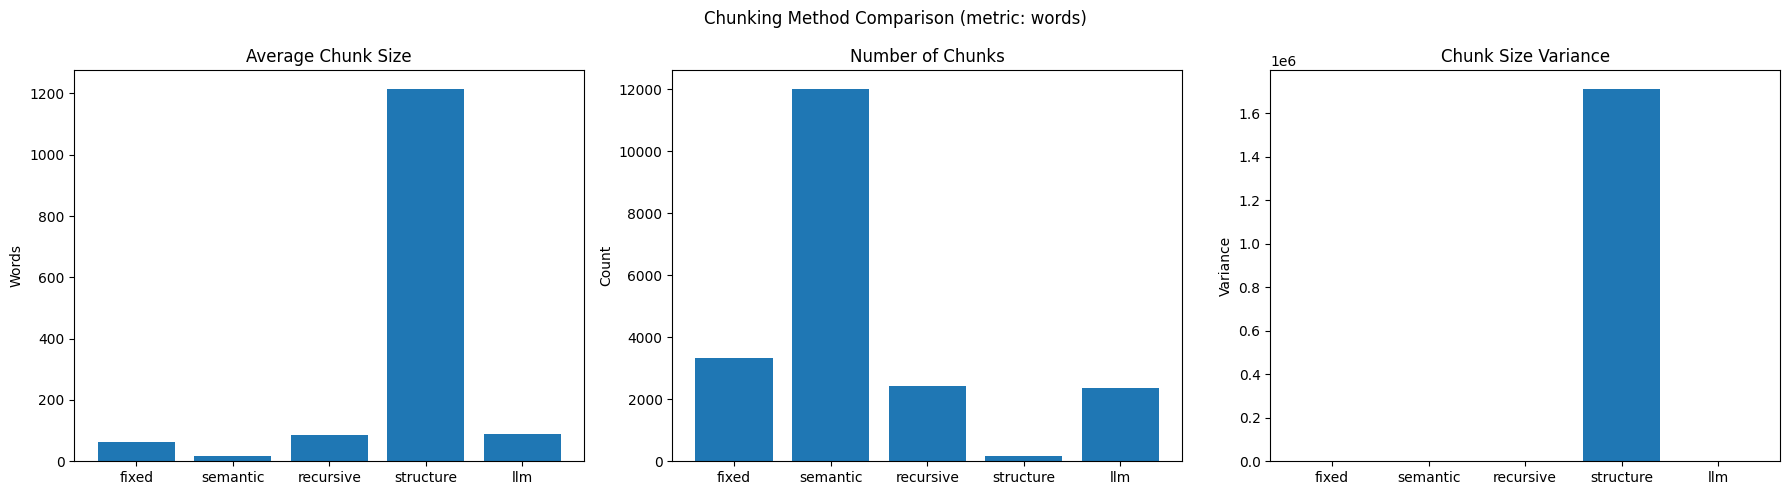

In [ ]:
# -------------------- Bar Plots --------------------
# Uses the computed df (no hardcoding)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Average Chunk Size
axes[0].bar(df["Method"], df["Avg Chunk Size"])
axes[0].set_title("Average Chunk Size")
axes[0].set_ylabel(
    {"chars": "Characters", "words": "Words", "tokens": "Tokens"}[METRIC]
)

# Number of Chunks
axes[1].bar(df["Method"], df["Num Chunks"])
axes[1].set_title("Number of Chunks")
axes[1].set_ylabel("Count")

# Chunk Size Variance
axes[2].bar(df["Method"], df["Size Variance"])
axes[2].set_title("Chunk Size Variance")
axes[2].set_ylabel("Variance")

plt.suptitle(f"Chunking Method Comparison (metric: {METRIC})")
plt.tight_layout()
plt.show()


/tmp/ipython-input-1307296014.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


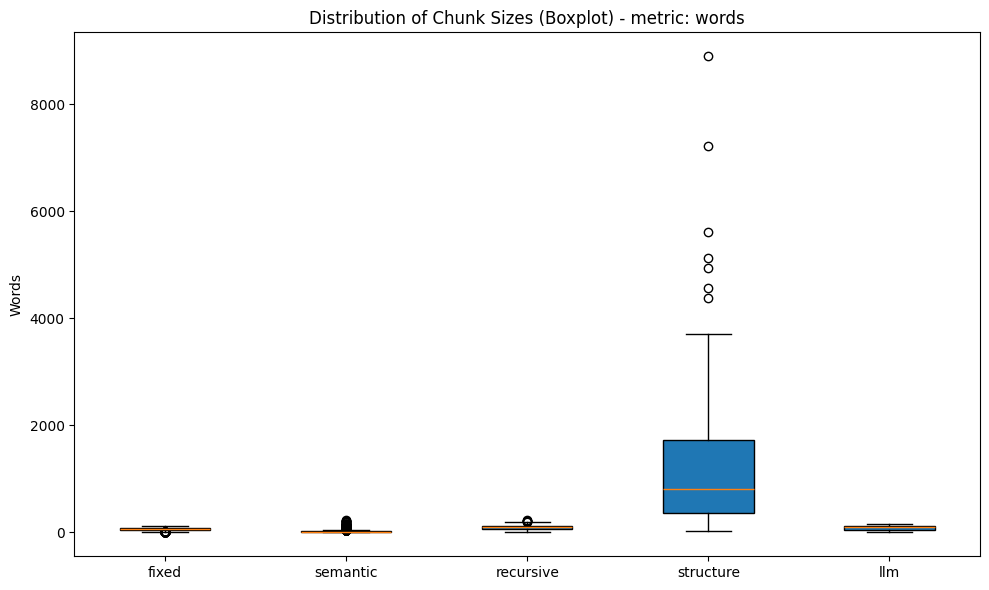

In [ ]:
# -------------------- Boxplot from raw chunk sizes --------------------
# (no hardcoding, uses existing chunk lists)

def extract_sizes(chunks, metric: str):
    return [_size_val(c, metric) for c in chunks]


# Extract sizes for each chunking method
sizes_fixed = extract_sizes(chunked_pages, METRIC)
sizes_semantic = extract_sizes(semantic_chunked_pages, METRIC)
sizes_recursive = extract_sizes(recursive_chunked_pages, METRIC)
sizes_structure = extract_sizes(structure_chunked_pages, METRIC)
sizes_llm = extract_sizes(llm_chunked_pages, METRIC)


# Create boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(
    [sizes_fixed, sizes_semantic, sizes_recursive, sizes_structure, sizes_llm],
    labels=["fixed", "semantic", "recursive", "structure", "llm"],
    patch_artist=True
)

plt.title(f"Distribution of Chunk Sizes (Boxplot) - metric: {METRIC}")
plt.ylabel(
    {"chars": "Characters", "words": "Words", "tokens": "Tokens"}[METRIC]
)
plt.tight_layout()
plt.show()


## Chunking — Final Takeaways
### Observations from Chunk Analysis

- **Structure-Based Chunking**
  - Produces **fewer chunks**
  - Chunk sizes are **very large**
  - **High variance** in chunk size
  - Good for capturing **entire sections**
  - ❌ Less balanced for downstream models due to size variance

- **Semantic Chunking**
  - Produces the **highest number of chunks**
  - Chunks are **very small**
  - Preserves **fine-grained semantic context**
  - ❌ Risk of **over-fragmentation**
    - Chunks may become too small to carry meaningful information

- **Fixed-Size Chunking**
  - Produces **consistent, moderate-sized chunks**
  - **Low variance** in chunk size
  - Easy to reason about and fast
  - ❌ Completely ignores semantic and structural boundaries

- **Recursive Chunking**
  - Balances **structure preservation** and **size control**
  - Avoids oversized chunks
  - Most **practical and production-friendly** approach

- **LLM-Based Chunking**
  - Semantically powerful but:
    - ❌ **Extremely slow** (orders of magnitude slower)
    - ❌ Computationally expensive
    - ❌ Not scalable
  - Suitable only for **small, high-value, highly unstructured data**

> **Important correction:**  
> If time benchmarking is included, **LLM-based chunking is clearly the slowest** and often impractical for real systems.

---

## Key Engineering Insight
- Chunking quality is not just about correctness — it is about:
  - **Chunk size variance**
  - **Number of chunks**
  - **Downstream model compatibility**
  - **Latency and cost**



## Further text processing (splitting pages into sentences)

In [ ]:
from spacy.lang.en import English  # see https://spacy.io/usage for install instructions

nlp = English()

# Add a sentencizer pipeline
nlp.add_pipe("sentencizer")

# Create a document instance as an example
doc = nlp("This is a sentence. This another sentence.")

# Validate sentence splitting
assert len(list(doc.sents)) == 2

# Access the sentences of the document
list(doc.sents)


[This is a sentence., This another sentence.]

In [6]:
# # -------------------- Add spaCy sentence splits to each page --------------------

# for item in tqdm(pages_and_texts):
#     # Extract sentences using spaCy
#     item["sentences"] = list(nlp(item["text"]).sents)

#     # Ensure all sentences are strings
#     item["sentences"] = [str(sentence) for sentence in item["sentences"]]

#     # Count number of sentences per page
#     item["page_sentence_count_spacy"] = len(item["sentences"])


In [ ]:
# Inspect an example
random.sample(pages_and_texts, k=1)


[{'page_number': 416,
  'page_char_count': 1389,
  'page_word_count': 255,
  'page_sentence_count_raw': 9,
  'page_token_count': 347.25,
  'text': 'Foods  Lacking Amino  Acids  Complementary  Food  Complementary  Menu  Legumes  Methionine,  tryptophan  Grains, nuts,  and seeds  Hummus and  whole-wheat pita  Grains  Lysine, isoleucine,  threonine  Legumes  Cornbread and  kidney bean chili  Nuts and  seeds  Lysine, isoleucine  Legumes  Stir-fried tofu with  cashews  The second component of protein quality is digestibility, as not  all protein sources are equally digested. In general, animal-based  proteins are completely broken down during the process of  digestion, whereas plant-based proteins are not. This is because  some proteins are contained in the plant’s fibrous cell walls and  these pass through the digestive tract unabsorbed by the body.  Protein Digestibility Corrected Amino Acid  Score (PDCAAS)  The PDCAAS is a method adopted by the US Food and Drug  Administration (FDA) to d

In [ ]:
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy
count,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1148.00,198.30,9.97,287.00,10.32
std,348.86,560.38,95.76,6.19,140.10,6.30
min,-41.00,0.00,1.00,1.00,0.00,0.00
25%,260.75,762.00,134.00,4.00,190.50,5.00
50%,562.50,1231.50,214.50,10.00,307.88,10.00
75%,864.25,1603.50,271.00,14.00,400.88,15.00
max,1166.00,2308.00,429.00,32.00,577.00,28.00


In [7]:
# # Define split size to turn groups of sentences into chunks
# num_sentence_chunk_size = 10


# def split_list(input_list: list, slice_size: int) -> list[list[str]]:
#     """
#     Splits the input_list into sublists of size `slice_size`
#     (or as close as possible).

#     Example:
#     A list of 17 sentences with slice_size=10 →
#     [[10 sentences], [7 sentences]]
#     """

#     return [
#         input_list[i:i + slice_size]
#         for i in range(0, len(input_list), slice_size)
#     ]


# # Loop through pages and split sentences into sentence-level chunks
# for item in tqdm(pages_and_texts):
#     item["sentence_chunks"] = split_list(
#         input_list=item["sentences"],
#         slice_size=num_sentence_chunk_size
#     )

#     # Store number of sentence chunks per page
#     item["num_chunks"] = len(item["sentence_chunks"])


In [ ]:
# Sample an example from the group
# (note: many samples have only 1 chunk as they have <= 10 sentences total)
random.sample(pages_and_texts, k=1)


[{'page_number': 244,
  'page_char_count': 1413,
  'page_word_count': 251,
  'page_sentence_count_raw': 13,
  'page_token_count': 353.25,
  'text': 'your body senses blood glucose levels and maintains the glucose  “temperature” in the target range. The glucose thermostat is located  within the cells of the pancreas. After eating a meal containing  carbohydrates glucose levels rise in the blood.  Insulin-secreting cells in the pancreas sense the increase in blood  glucose and release the hormone, insulin, into the blood. Insulin  sends a signal to the body’s cells to remove glucose from the blood  by transporting it into different organ cells around the body and  using it to make energy. In the case of muscle tissue and the liver,  insulin sends the biological message to store glucose away as  glycogen. The presence of insulin in the blood signifies to the body  that glucose is available for fuel. As glucose is transported into the  cells around the body, the blood glucose levels decrea

In [ ]:
# Create a DataFrame from pages_and_texts to inspect statistics
df = pd.DataFrame(pages_and_texts)

# Show descriptive statistics
df.describe().round(2)


,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy,num_chunks
count,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1148.00,198.30,9.97,287.00,10.32,1.53
std,348.86,560.38,95.76,6.19,140.10,6.30,0.64
min,-41.00,0.00,1.00,1.00,0.00,0.00,0.00
25%,260.75,762.00,134.00,4.00,190.50,5.00,1.00
50%,562.50,1231.50,214.50,10.00,307.88,10.00,1.00
75%,864.25,1603.50,271.00,14.00,400.88,15.00,2.00
max,1166.00,2308.00,429.00,32.00,577.00,28.00,3.00


### Splitting each chunk into its own item

We'd like to embed each chunk of sentences into its own numerical representation.

So to keep things clean, let's create a new list of dictionaries each containing a single chunk of sentences with relative information, page number as well statistics about each chunk.


In [8]:
# import re

# # Split each chunk into its own item
# pages_and_chunks = []

# for item in tqdm(pages_and_texts):
#     for sentence_chunk in item["sentence_chunks"]:
#         chunk_dict = {}

#         # Store page number
#         chunk_dict["page_number"] = item["page_number"]

#         # Join sentences into a single chunk
#         joined_sentence_chunk = " ".join(sentence_chunk).replace("  ", " ").strip()

#         # Fix missing space after periods (".A" -> ". A")
#         joined_sentence_chunk = re.sub(
#             r'\.([A-Z])',
#             r'. \1',
#             joined_sentence_chunk
#         )

#         chunk_dict["sentence_chunk"] = joined_sentence_chunk

#         # Chunk statistics
#         chunk_dict["chunk_char_count"] = len(joined_sentence_chunk)
#         chunk_dict["chunk_word_count"] = len(
#             [word for word in joined_sentence_chunk.split(" ")]
#         )
#         chunk_dict["chunk_token_count"] = len(joined_sentence_chunk) / 4  # ~1 token = 4 chars

#         pages_and_chunks.append(chunk_dict)

# # How many chunks do we have?
# len(pages_and_chunks)


In [ ]:
random.sample(pages_and_chunks, k=1)

[{'page_number': 967,
  'sentence_chunk': 'Iron Status and Exercise. The American Journal of Clinical Nutrition, 72(2), 594S–597S. Sports Nutrition | 967',
  'chunk_char_count': 110,
  'chunk_word_count': 16,
  'chunk_token_count': 27.5}]

In [ ]:
# Create a DataFrame from pages_and_texts to inspect statistics
df = pd.DataFrame(pages_and_chunks)

# Show descriptive statistics
df.describe().round(2)


,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,1843.00,1843.00,1843.00,1843.00
mean,583.38,735.14,113.03,183.78
std,347.79,447.64,71.27,111.91
min,-41.00,12.00,3.00,3.00
25%,280.50,315.00,45.00,78.75
50%,586.00,747.00,114.00,186.75
75%,890.00,1119.00,174.00,279.75
max,1166.00,1832.00,298.00,458.00


In [ ]:
# Show random chunks with under 30 tokens in length
min_token_length = 30

for _, row in df[df["chunk_token_count"] <= min_token_length].sample(5).iterrows():
    print(
        f"Chunk token count: {row['chunk_token_count']} | "
        f"Text: {row['sentence_chunk']}"
    )


Chunk token count: 3.25 | Text: 814 | Infancy
Chunk token count: 12.5 | Text: Figure 11.2 The Structure of Hemoglobin Iron | 655
Chunk token count: 9.25 | Text: Protein’s Functions in the Body | 387
Chunk token count: 26.0 | Text: http://www.ncbi.nlm.nih.gov/pubmed/20182023. Accessed September 22, 2017. 220 | Popular Beverage Choices
Chunk token count: 17.5 | Text: The Obesity Myth. Gotham Books. Calories In Versus Calories Out | 1069


### Observation

Looks like many of these are **headers and footers** of different pages.

They don't seem to offer **too much information**.

### Next Step

Filter our **DataFrame / list of dictionaries** to only include chunks with **over 30 tokens** in length.


In [ ]:
pages_and_chunks_over_min_token_len = (
    df[df["chunk_token_count"] > min_token_length]
    .to_dict(orient="records")
)

pages_and_chunks_over_min_token_len[:2]


[{'page_number': -39,
  'sentence_chunk': 'Human Nutrition: 2020 Edition UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN NUTRITION PROGRAM ALAN TITCHENAL, SKYLAR HARA, NOEMI ARCEO CAACBAY, WILLIAM MEINKE-LAU, YA-YUN YANG, MARIE KAINOA FIALKOWSKI REVILLA, JENNIFER DRAPER, GEMADY LANGFELDER, CHERYL GIBBY, CHYNA NICOLE CHUN, AND ALLISON CALABRESE',
  'chunk_char_count': 308,
  'chunk_word_count': 42,
  'chunk_token_count': 77.0},
 {'page_number': -38,
  'sentence_chunk': 'Human Nutrition: 2020 Edition by University of Hawai‘i at Mānoa Food Science and Human Nutrition Program is licensed under a Creative Commons Attribution 4.0 International License, except where otherwise noted.',
  'chunk_char_count': 210,
  'chunk_word_count': 30,
  'chunk_token_count': 52.5}]

### Embedding our text chunks

While humans understand text, machines understand numbers best.

An embedding is a broad concept.

But one of my favourite and simple definitions is **“a useful numerical representation.”**

The most powerful thing about modern embeddings is that they are **learned representations**.

Meaning rather than directly mapping words / tokens / characters to numbers directly  
(e.g. `{"a": 0, "b": 1, "c": 3 ...}`), the numerical representation of tokens is learned by going through large corpuses of text and figuring out how different tokens relate to each other.

Ideally, embeddings of text will mean that **similar meaning texts have similar numerical representations**.

---

### Note on Tokens

Most modern NLP models deal with **tokens**, which can be considered as multiple different sizes and combinations of words and characters rather than always whole words or single characters.

For example, the string:



**"hello world!"**


gets mapped to token values:

**{15339: b'hello', 1917: b' world', 0: b'!'}**


using **Byte Pair Encoding (BPE)** via OpenAI’s `tiktoken` library.

Google has a tokenization library called **SentencePiece**.

---

In [9]:
# from sentence_transformers import SentenceTransformer

# # Load embedding model
# embedding_model = SentenceTransformer(
#     model_name_or_path="all-mpnet-base-v2",
#     device="cpu"  # choose device (GPU if available)
# )

# # Create a list of sentences to turn into embeddings
# sentences = [
#     "The Sentences Transformers library provides an easy and open-source way to create embeddings.",
#     "Sentences can be embedded one by one or as a list of strings.",
#     "Embeddings are one of the most powerful concepts in machine learning!",
#     "Learn to use embeddings well and you'll be well on your way to being an AI engineer."
# ]

# # Encode sentences into embeddings
# embeddings = embedding_model.encode(sentences)

# # Map sentences to their embeddings
# embeddings_dict = dict(zip(sentences, embeddings))

# # Inspect embeddings
# for sentence, embedding in embeddings_dict.items():
#     print("Sentence:", sentence)
#     print("Embedding:", embedding)
#     print()


In [ ]:
single_sentence = "Yo! How cool are embeddings?"

single_embedding = embedding_model.encode(single_sentence)

print(f"Sentence: {single_sentence}")
print(f"Embedding:\n{single_embedding}")
print(f"Embedding size: {single_embedding.shape}")


Sentence: Yo! How cool are embeddings?
Embedding:
[-1.97447427e-02 -4.51086881e-03 -4.98485053e-03  6.55445009e-02
 -9.87679232e-03  2.72835400e-02  3.66426297e-02 -3.30218766e-03
  8.50079488e-03  8.24953429e-03 -2.28496902e-02  4.02430221e-02
 -5.75200692e-02  6.33693114e-02  4.43207026e-02 -4.49507199e-02
  1.25284074e-02 -2.52012592e-02 -3.55292559e-02  1.29559208e-02
  8.67017172e-03 -1.92917418e-02  3.55633581e-03  1.89505871e-02
 -1.47128394e-02 -9.39850323e-03  7.64166377e-03  9.62190889e-03
 -5.98926842e-03 -3.90170179e-02 -5.47824502e-02 -5.67451864e-03
  1.11644585e-02  4.08067852e-02  1.76319122e-06  9.15295724e-03
 -8.77268612e-03  2.39383057e-02 -2.32784506e-02  8.04999471e-02
  3.19177508e-02  5.12592029e-03 -1.47708794e-02 -1.62525047e-02
 -6.03212789e-02 -4.35689688e-02  4.51210849e-02 -1.79053862e-02
  2.63366923e-02 -3.47867236e-02 -8.89174361e-03 -5.47675230e-02
 -1.24372840e-02 -2.38606390e-02  8.33497047e-02  5.71242571e-02
  1.13328639e-02 -1.49595207e-02  9.2037

In [10]:
# %%time

# # Make sure the model is on the CPU
# embedding_model.to("cpu")

# # Embed each chunk one by one
# for item in tqdm(pages_and_chunks_over_min_token_len):
#     item["embedding"] = embedding_model.encode(item["sentence_chunk"])


In [11]:
# %%time

# # Send the model to the GPU
# embedding_model.to("cuda")  # requires a GPU

# # Create embeddings one by one on the GPU
# for item in tqdm(pages_and_chunks_over_min_token_len):
#     item["embedding"] = embedding_model.encode(item["sentence_chunk"])


In [ ]:
# Turn text chunks into a single list
text_chunks = [
    item["sentence_chunk"]
    for item in pages_and_chunks_over_min_token_len
]

In [ ]:
%%time

# Embed all texts in batches
text_chunk_embeddings = embedding_model.encode(
    text_chunks,
    batch_size=32,            # adjust batch size if needed
    convert_to_tensor=True    # return embeddings as tensors
)

text_chunk_embeddings


CPU times: user 26.6 s, sys: 49.1 ms, total: 26.6 s
Wall time: 26.2 s


tensor([[ 0.0674,  0.0902, -0.0051,  ..., -0.0221, -0.0232,  0.0126],
        [ 0.0552,  0.0592, -0.0166,  ..., -0.0120, -0.0103,  0.0227],
        [ 0.0280,  0.0340, -0.0206,  ..., -0.0054,  0.0213,  0.0313],
        ...,
        [ 0.0771,  0.0098, -0.0122,  ..., -0.0409, -0.0752, -0.0241],
        [ 0.1030, -0.0165,  0.0083,  ..., -0.0574, -0.0283, -0.0295],
        [ 0.0864, -0.0125, -0.0113,  ..., -0.0522, -0.0337, -0.0299]],
       device='cuda:0')

### Save embeddings to file

Since creating embeddings can be a timely process (not so much for our case but it can be for more larger datasets), let's turn our `pages_and_chunks_over_min_token_len` list of dictionaries into a DataFrame and save it.


In [ ]:
# Save embeddings to file
text_chunks_and_embeddings_df = pd.DataFrame(pages_and_chunks_over_min_token_len)

embeddings_df_save_path = "text_chunks_and_embeddings_df.csv"

text_chunks_and_embeddings_df.to_csv(
    embeddings_df_save_path,
    index=False
)


In [ ]:
# Import saved file and view
text_chunks_and_embedding_df_load = pd.read_csv(embeddings_df_save_path)
text_chunks_and_embedding_df_load.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-39,Human Nutrition: 2020 Edition UNIVERSITY OF HA...,308,42,77.0,[ 6.74242675e-02 9.02281404e-02 -5.09548886e-...
1,-38,Human Nutrition: 2020 Edition by University of...,210,30,52.5,[ 5.52156419e-02 5.92139773e-02 -1.66167244e-...
2,-37,Contents Preface University of Hawai‘i at Māno...,766,114,191.5,[ 2.79801842e-02 3.39813754e-02 -2.06426680e-...
3,-36,Lifestyles and Nutrition University of Hawai‘i...,942,143,235.5,[ 6.82566911e-02 3.81275006e-02 -8.46854132e-...
4,-35,The Cardiovascular System University of Hawai‘...,998,152,249.5,[ 3.30264494e-02 -8.49763490e-03 9.57159605e-...


## Embeddings — Engineering Decisions (After Chunking)

Once chunking is complete, **each chunk is converted into a vector embedding**.
At this stage, embeddings become the **numerical representation of meaning** that powers retrieval.

Two **critical engineering decisions** arise here:

1. **Which embedding model should be used?**
2. **How should embeddings be handled at different scales?**

These choices directly affect:
- Retrieval quality
- Cost
- Latency
- Scalability

---

## 1. Choosing an Embedding Model

There is **no universally best embedding model**.  
Embedding selection is always a **trade-off across multiple dimensions**.

---

### 1️⃣ Input Capacity (Max Tokens per Chunk)

- Defines **how long a chunk** the model can embed
- Must align with:
  - Chunking strategy
  - Maximum chunk size
- If chunks are long, smaller models may **truncate input**, losing information

**Guidelines**
- Large chunks → choose models with **high token capacity**
- Small chunks → lightweight models are sufficient

**Engineering Insight**
- Chunking and embedding model choice are **coupled decisions**
- Poor alignment leads to silent information loss

---

### 2️⃣ Embedding Vector Size (Dimensionality)

- Determines **how much semantic detail** is captured
- Larger vectors:
  - Encode richer meaning
  - Handle complex relationships better

**Especially useful for**
- Numeric-heavy text
- Tables
- Mixed-format documents
- Technical or domain-specific data

**Trade-off**
- Larger vectors require:
  - More compute
  - More memory
  - Slower similarity operations

**Rule of Thumb**
- Simple natural language → smaller embeddings
- Complex, dense, or structured data → larger embeddings

---

### 3️⃣ Model Size (Number of Parameters)

- Larger models:
  - Better semantic understanding
  - Capture subtle relationships
- Smaller models:
  - Faster
  - Cheaper
  - Easier to deploy

**Observed Pattern**
- Top-performing embedding models are typically **large and compute-heavy**
- Performance gains are real, but **cost grows rapidly**

**Engineering Reality**
- Model size must be justified by:
  - Retrieval quality gains
  - Business value
  - Latency constraints

---

### 4️⃣ Open-Source vs Closed-Source Embeddings

#### Open-Source Embedding Models
- Run on your own infrastructure
- Best for:
  - Privacy-sensitive data
  - Cost control
  - On-prem or restricted environments

**Characteristics**
- More setup
- Full control
- Predictable cost

---

#### Closed-Source Embedding Models
- Accessed via APIs
- Often state-of-the-art performance

**Characteristics**
- Minimal setup
- Higher accuracy
- Ongoing API cost
- Less control

---

**Trade-off Summary**
- Open-source → control, privacy, flexibility
- Closed-source → convenience, performance

---

## Summary: Embedding Model Selection Axes

Every embedding decision balances:

- **Input capacity** → can the model handle your chunk size?
- **Vector dimensionality** → semantic richness vs cost
- **Model size** → accuracy vs latency
- **Open vs closed** → control vs convenience

There is no default choice — only **context-dependent decisions**.

---

## 2. Handling Embeddings by Scale (High-Level)

> *(Storage systems are intentionally not discussed in detail here)*

### Small-Scale / Experimentation
- For small datasets (≈ under 100k chunks):
  - In-memory arrays (NumPy / Torch) are sufficient
- Ideal for:
  - Prototyping
  - Research
  - Local experimentation

### Production-Scale Consideration
- As embedding count grows:
  - Naive storage and search become inefficient
- At scale, **specialized systems are required**  
  *(covered later in the pipeline)*

---

## Practical Engineering Guidance

- Chunk size and embedding choice must be **designed together**
- Larger chunks require:
  - Higher input capacity
  - Stronger models
- Better embeddings → better retrieval → better RAG answers
- Always balance:
  - Performance
  - Cost
  - Latency
  - Privacy
  - Scale

---


## Embeddings Storage & Vector Indexing — Engineering Decisions

Once embeddings are generated, the **next critical engineering question** is:

> **Where should embeddings be stored for efficient retrieval?**

Many people immediately answer **“vector database”**, but that is **neither intuitive nor always correct**.

This decision depends on:
- Scale of data
- Retrieval latency requirements
- Indexing needs
- System complexity
- Operational constraints

---

## Intuitive First Thought (Before Vector Databases)

### Why not just store embeddings as arrays?

- Embeddings are just numeric vectors
- Each chunk → one vector (e.g., 768 dimensions)
- Example:
  - 1,680 chunks × 768-dim vectors
- Can be stored as:
  - `numpy.ndarray`
  - `torch.tensor`
  - CSV / binary files

**This is a completely valid approach for small datasets.**

---

## When Simple Arrays Are Enough

### Small-Scale Systems
- Dataset size: **< ~100,000 embeddings** *(rough, experience-based threshold)*
- Retrieval:
  - Compute cosine similarity
  - Scan all vectors

**Why this works**
- Compute cost is manageable
- Memory fits easily
- No infrastructure overhead

**Typical use cases**
- Prototypes
- Research experiments
- Local RAG systems
- Small internal tools

**Conclusion**
> For small datasets, **vector databases are unnecessary**.

---

## Why Vector Databases Exist

### The Core Problem at Scale

When embeddings grow to:
- 100k+
- 1M+
- 10M+

A naive full-scan approach fails because:
- Each query compares against millions of vectors
- Latency becomes unacceptable
- Compute cost explodes

**This is not a storage problem — it is an indexing problem.**

---

## What Vector Databases Actually Solve

Vector databases are **not magic storage systems**.

Their real value lies in:
> **Efficient nearest-neighbor indexing for similarity search**

Indexing allows:
- Avoiding full scans
- Searching only a small subset of vectors
- Fast approximate nearest neighbor (ANN) retrieval

---

## Core Indexing Ideas

### 1️⃣ Cluster-Based Indexing (IVF Flat)

- Vectors are clustered into lists
- Query:
  - Finds nearest cluster centroid
  - Searches only within selected clusters
- Similar to **K-means-style partitioning**

**Key idea**
> Reduce search space before similarity computation

---

### 2️⃣ Graph-Based Indexing (HNSW)

- Vectors form a **multi-layer graph**
- Search process:
  1. Start at sparse top layer
  2. Navigate toward closer neighbors
  3. Refine search in dense lower layers

**Key properties**
- Very fast query time
- Higher memory usage
- Slower index build time
- Excellent recall-speed tradeoff

---

## IVF Flat vs HNSW — Detailed Comparison

| Feature | IVF Flat | HNSW |
|------|---------|------|
| **Indexing mechanism** | Clusters vectors into lists (centroid-based) | Multi-layer graph-based structure |
| **Memory usage** | Lower | Higher |
| **Index build time** | Faster | Slower |
| **Speed–recall tradeoff** | Adjustable via parameters | Generally superior |
| **Sensitivity to data size** | Best up to ~1M vectors | Scales well to large datasets |
| **Query performance** | Good for moderate workloads | Excellent for high-throughput |
| **Adaptability to updates** | Re-indexing often needed | More resilient to incremental changes |

**Engineering insight**
- **IVF Flat** → faster setup, lower memory, medium-scale systems
- **HNSW** → best latency, higher memory, production-grade systems

---

## Vector Search Tools — What They Are

### Libraries
- **FAISS**
  - Similarity search library
  - No database features
  - You manage storage, persistence, metadata

---

### Vector Databases
- **Pinecone**
  - Managed, cloud-based
  - Indexing fully abstracted
- **Milvus**
  - Open-source, large-scale
- **Weaviate**
  - Open-source, metadata + hybrid search
- **Qdrant**
  - Open-source, Rust-based, high performance
- **Chroma**
  - Lightweight, good for prototyping

---

## Important Distinction: FAISS vs Vector Databases

- **FAISS**
  - Algorithmic tool
  - No persistence layer
  - No metadata management

- **Vector Databases**
  - Full systems
  - Handle:
    - Storage
    - Indexing
    - Scaling
    - Metadata
    - Persistence

**Rule**
> FAISS = similarity engine  
> Vector DB = production system

---

## The Metadata Synchronization Problem

Using:
- One database for application data (SQL / NoSQL)
- One vector database for embeddings

Creates issues:
- Metadata duplication
- Cross-database joins
- Synchronization complexity

This increases **engineering friction**.

---

## Unified Approach: SQL + Embeddings Together

### Key Idea
> Store embeddings and structured data in the **same database**

This is achieved using **PostgreSQL + vector extensions (pgvector)**.

---

## Why This Works Well

- Single database for:
  - User data
  - Metadata
  - Application state
  - Embeddings
- Full SQL support:
  - Joins
  - Filters
  - Constraints
- Mature, battle-tested ecosystem

**Principle Applied**
> Reduce new problems to already-solved ones (SQL).

---

## Indexing Still Matters Here

Even with SQL-based storage:
- Indexes are mandatory for performance
- Same concepts apply:
  - IVF-style indexing
  - HNSW-style indexing

Index choice impacts:
- Insert time
- Query latency
- Memory usage

---

## Database-Level Feature Comparison (High-Level)

| Feature | Pinecone | Qdrant | Weaviate | Milvus | Chroma | OpenSearch | Postgres (pgvector) |
|------|---------|--------|----------|--------|--------|-----------|---------------------|
| Purpose-built for vectors | ✅ | ✅ | ✅ | ✅ | ✅ | ❌ | ❌ |
| Managed cloud | ✅ | ❌ | ❌ | ❌ | ❌ | ❌ | ❌ |
| Self-hosted | ❌ | ✅ | ✅ | ✅ | ✅ | ✅ | ✅ |
| Open-source | ❌ | ✅ | ✅ | ✅ | ✅ | ✅ | ✅ |
| SQL support | ❌ | ❌ | ❌ | ❌ | ❌ | ❌ | ✅ |
| Supported index types | HNSW, DiskANN | HNSW | HNSW | HNSW, IVF | HNSW | HNSW, IVF | HNSW, IVF |
| Metadata filtering | ✅ | ✅ | ✅ | ✅ | ✅ | ✅ | ✅ |

---

## Final Engineering Decision Flow

1. **< 100k embeddings**
   - Arrays / tensors
   - Brute-force similarity

2. **Large-scale retrieval**
   - Indexed ANN search

3. **Want managed infrastructure**
   - Dedicated vector databases

4. **Want unified data + embeddings**
   - PostgreSQL + pgvector

---

## Core Takeaways

- Vector databases exist because of **indexing**, not storage
- Small datasets do **not** need vector databases
- Indexing strategy matters more than vendor choice
- HNSW → best performance
- IVF Flat → fastest setup
- PostgreSQL + pgvector → best for unified architectures




In [ ]:
from sentence_transformers import util, SentenceTransformer
import torch # Import torch to check for CUDA availability

# Define the device
device = "cuda" if torch.cuda.is_available() else "cpu"

embedding_model = SentenceTransformer(
    model_name_or_path="all-mpnet-base-v2",
    device=device  # choose the device to load the model to
)


In [ ]:
# 1. Define the query
# Note: This could be anything. But since we're working with a nutrition textbook,
# we'll stick with nutrition-based queries.
query = "macronutrients functions"
print(f"Query: {query}")

# 2. Embed the query to the same numerical space as the text examples
# Note: Use the same embedding model as the chunks
query_embedding = embedding_model.encode(
    query,
    convert_to_tensor=True
)

# 3. Get similarity scores with the dot product
from time import perf_counter as timer
import torch
from sentence_transformers import util

start_time = timer()
dot_scores = util.dot_score(
    a=query_embedding,
    b=text_chunk_embeddings # Changed from 'embeddings' to 'text_chunk_embeddings'
)[0]
end_time = timer()

print(
    f"Time taken to get scores on {len(text_chunk_embeddings)} embeddings: "
    f"{end_time - start_time:.5f} seconds."
)

# 4. Get the top-k results
top_results_dot_product = torch.topk(dot_scores, k=5)
top_results_dot_product

Query: macronutrients functions
Time taken to get scores on 1680 embeddings: 0.02605 seconds.


torch.return_types.topk(
values=tensor([0.6926, 0.6738, 0.6646, 0.6536, 0.6473], device='cuda:0'),
indices=tensor([42, 47, 41, 51, 46], device='cuda:0'))

In [ ]:
# Create a larger embedding matrix for timing comparison
larger_embeddings = torch.randn(
    100 * embeddings.shape[0],
    768
).to(device)

print(f"Embeddings shape: {larger_embeddings.shape}")

# Perform dot product across larger embeddings
start_time = timer()
dot_scores = util.dot_score(
    a=query_embedding,
    b=larger_embeddings
)[0]
end_time = timer()

print(
    f"Time taken to get scores on {len(larger_embeddings)} embeddings: "
    f"{end_time - start_time:.5f} seconds."
)


Embeddings shape: torch.Size([400, 768])
Time taken to get scores on 400 embeddings: 0.00048 seconds.


In [ ]:
# Define helper function to print wrapped text
import textwrap

def print_wrapped(text, wrap_length=80):
    wrapped_text = textwrap.fill(text, wrap_length)
    print(wrapped_text)


In [ ]:
print(f"Query: '{query}'\n")
print("Results")

# Loop through zipped scores and indices from torch.topk
for score, idx in zip(top_results_dot_product[0], top_results_dot_product[1]):
    print(f"Score: {score:.4f}")

    # Print relevant sentence chunk
    print("Text:")
    print_wrapped(pages_and_chunks[idx]["sentence_chunk"])

    # Print page number for reference
    print(f"Page number: {pages_and_chunks[idx]['page_number']}")
    print("\n")


Query: 'macronutrients functions'

Results
Score: 0.6926
Text:
Image by Jim Hollyer / CC BY 4.0 Introduction UNIVERSITY OF HAWAI‘I AT MĀNOA
FOOD SCIENCE AND HUMAN NUTRITION PROGRAM AND HUMAN NUTRITION PROGRAM ʻO ke kahua
ma mua, ma hope ke kūkulu The foundation comes first, then the building    
Introduction | 3
Page number: 3


Score: 0.6738
Text:
Lipids are found predominantly in butter, oils, meats, dairy products, nuts, and
seeds, and in many processed foods. The three main types of lipids are
triglycerides (triacylglycerols), phospholipids, and sterols. The main job of
lipids is to provide or store energy. Lipids provide more energy per gram than
carbohydrates (nine kilocalories per gram of lipids versus four kilocalories per
gram of carbohydrates). In addition to energy storage, lipids serve as a major
component of cell membranes, surround and protect organs (in fat-storing
tissues), provide insulation to aid in temperature regulation, and regulate many
other functions in the bod

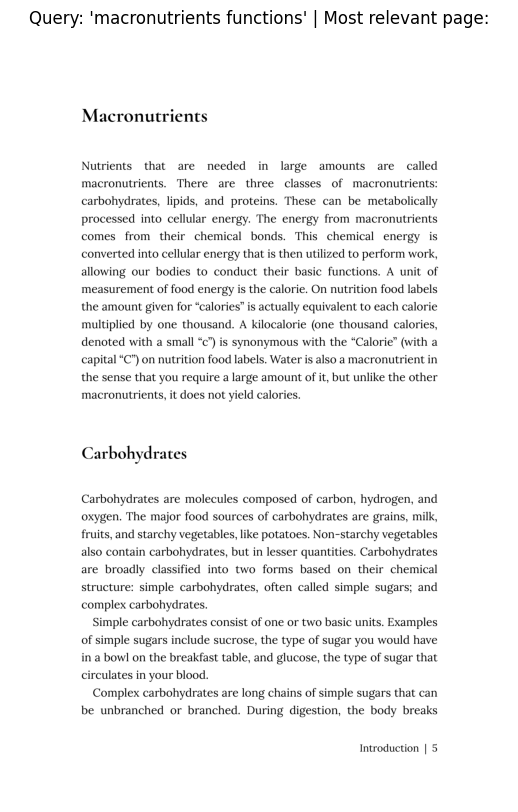

In [ ]:
import fitz

# Open PDF and load target page
pdf_path = "human-nutrition-text.pdf" # requires PDF to be downloaded
doc = fitz.open(pdf_path)
page = doc.load_page(5 + 41) # number of page (our doc starts page numbers on page 41)

# Get the image of the page
img = page.get_pixmap(dpi=300)

# Optional: save the image
#img.save("output_filename.png")
doc.close()

# Convert the Pixmap to a numpy array
img_array = np.frombuffer(img.samples_mv,
dtype=np.uint8).reshape((img.h, img.w, img.n))

# Display the image using Matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(13, 10))
plt.imshow(img_array)
plt.title(f"Query: '{query}' | Most relevant page:")
plt.axis('off') # Turn off axis
plt.show()

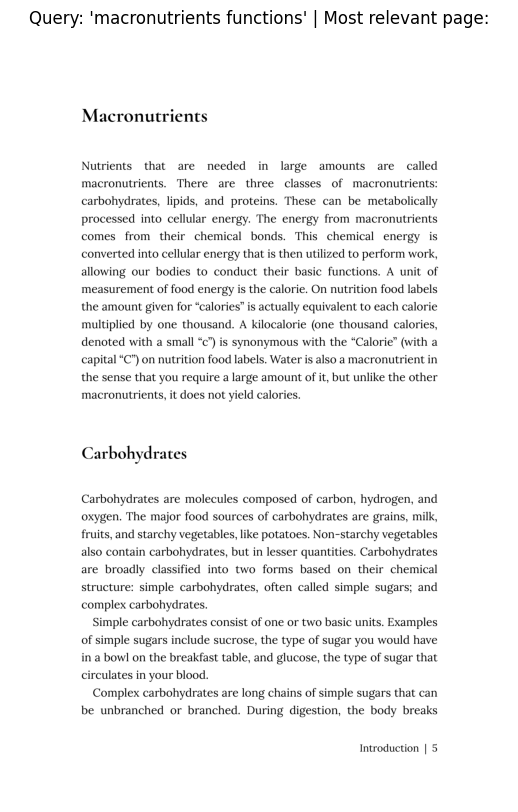

In [ ]:
import fitz
import numpy as np
import matplotlib.pyplot as plt

# Open PDF and load target page
pdf_path = "human-nutrition-text.pdf"  # requires PDF to be downloaded
doc = fitz.open(pdf_path)

# Load page (our document page numbering starts at page 41)
page = doc.load_page(5 + 41)

# Get the image of the page
img = page.get_pixmap(dpi=300)

# Optional: save the image
img.save("output_filename.png")

# Close the document
doc.close()

# Convert the Pixmap to a numpy array
img_array = np.frombuffer(
    img.samples_mv,
    dtype=np.uint8
).reshape((img.h, img.w, img.n))

# Display the image using Matplotlib
plt.figure(figsize=(13, 10))
plt.imshow(img_array)
plt.title(f"Query: '{query}' | Most relevant page:")
plt.axis("off")  # Turn off axis
plt.show()

## Similarity Measures for Embeddings (Dot Product vs Cosine Similarity)

### Why Similarity Measures Matter
- After embeddings are created, **retrieval = finding vectors most similar to the query vector**
- Similarity measures decide **which chunks are retrieved**
- Works for **any embeddings**:
  - Text
  - Images
  - Audio
  - Multimodal (e.g., CLIP: text ↔ image)

---

## Embedding Vectors (Quick Reminder)
- Embeddings are **high-dimensional vectors** (e.g., 768 dims)
- Each vector has:
  - **Magnitude** (length)
  - **Direction** (semantic meaning)

For semantic retrieval, **direction matters more than magnitude**.

---

## 1. Dot Product

### Definition
- Measures similarity by multiplying corresponding vector components and summing them

### Properties
- Sensitive to:
  - Direction
  - Magnitude
- Larger magnitude vectors → larger dot product

### Pros
- Very **fast**
- Simple computation
- No normalization step

### Cons
- If vectors are not normalized, magnitude can dominate similarity

---

## 2. Cosine Similarity (Most Common for Text)

### Definition
- Measures **angle between two vectors**
- Focuses on **direction**, not magnitude

### Formula (Conceptual)
$$
\text{cosine_similarity}(A, B) = \frac{A \cdot B}{\lVert A \rVert \times \lVert B \rVert}
$$



### Properties
- Vectors are **normalized by L2 norm**
- Output range:
  - `+1` → same direction (very similar)
  - `0` → orthogonal (unrelated)
  - `-1` → opposite direction

### Why It’s Preferred for Text
- Semantic meaning lives in **direction**
- Vector length does not matter
- Stable across different embedding magnitudes

---

## Dot Product vs Cosine Similarity (Key Insight)

### Important Optimization
- Many modern embedding models (e.g. **all-mpnet-base-v2**)  
  **already output normalized vectors**

➡️ If vectors are already normalized:
- **Dot Product == Cosine Similarity**
- Dot product is preferred because it’s **faster**

---

## Practical Rule of Thumb

- **If embeddings are normalized**
  → Use **dot product** (faster)

- **If embeddings are NOT normalized**
  → Use **cosine similarity**

---

## Common Libraries / Implementations

- `torch.dot`
- `np.dot`
- `sentence_transformers.util.dot_score`
- `torch.nn.functional.cosine_similarity`

---

## Summary Table

| Aspect | Dot Product | Cosine Similarity |
|-----|------------|------------------|
| Uses magnitude | ✅ | ❌ |
| Uses direction | ✅ | ✅ |
| Normalization needed | ❌ | ✅ |
| Speed | Faster | Slower |
| Best for text embeddings | ⚠️ (if normalized) | ✅ |
| Output range | Unbounded | [-1, 1] |

---

## Final Takeaway
- **Semantic retrieval = direction-based similarity**
- Cosine similarity is conceptually correct
- Dot product is computationally optimal **when embeddings are normalized**
- Always check whether your embedding model outputs **unit-normalized vectors**


In [ ]:
import torch


def dot_product(vector1, vector2):
    return torch.dot(vector1, vector2)


def cosine_similarity(vector1, vector2):
    dot = torch.dot(vector1, vector2)

    # Get Euclidean / L2 norm of each vector
    norm_vector1 = torch.sqrt(torch.sum(vector1 ** 2))
    norm_vector2 = torch.sqrt(torch.sum(vector2 ** 2))

    return dot / (norm_vector1 * norm_vector2)


# Example tensors
vector1 = torch.tensor([1, 2, 3], dtype=torch.float32)
vector2 = torch.tensor([1, 2, 3], dtype=torch.float32)
vector3 = torch.tensor([4, 5, 6], dtype=torch.float32)
vector4 = torch.tensor([-1, -2, -3], dtype=torch.float32)

# Calculate dot product
print("Dot product between vector1 and vector2:", dot_product(vector1, vector2))
print("Dot product between vector1 and vector3:", dot_product(vector1, vector3))
print("Dot product between vector1 and vector4:", dot_product(vector1, vector4))

# Calculate cosine similarity
print("Cosine similarity between vector1 and vector2:", cosine_similarity(vector1, vector2))
print("Cosine similarity between vector1 and vector3:", cosine_similarity(vector1, vector3))
print("Cosine similarity between vector1 and vector4:", cosine_similarity(vector1, vector4))


Dot product between vector1 and vector2: tensor(14.)
Dot product between vector1 and vector3: tensor(32.)
Dot product between vector1 and vector4: tensor(-14.)
Cosine similarity between vector1 and vector2: tensor(1.0000)
Cosine similarity between vector1 and vector3: tensor(0.9746)
Cosine similarity between vector1 and vector4: tensor(-1.0000)


In [ ]:
def retrieve_relevant_resources(
    query: str,
    embeddings: torch.Tensor,
    model: SentenceTransformer = embedding_model,
    n_resources_to_return: int = 5,
    print_time: bool = True
):
    """
    Embeds a query with the given model and returns the top-k
    similarity scores and indices from the embeddings.
    """

    # Embed the query
    query_embedding = model.encode(
        query,
        convert_to_tensor=True
    )

    # Get dot product similarity scores
    start_time = timer()
    dot_scores = util.dot_score(
        query_embedding,
        embeddings
    )[0]
    end_time = timer()

    if print_time:
        print(
            f"[INFO] Time taken to get scores on {len(embeddings)} embeddings: "
            f"{end_time - start_time:.5f} seconds."
        )

    # Get top-k results
    scores, indices = torch.topk(
        input=dot_scores,
        k=n_resources_to_return
    )

    return scores, indices

def print_top_results_and_scores(
    query: str,
    embeddings: torch.Tensor,
    pages_and_chunks: list[dict] = pages_and_chunks_over_min_token_len, # Corrected: use pre-filtered chunk list
    n_resources_to_return: int = 5
):
    """
    Takes a query, retrieves the most relevant resources,
    and prints them in descending order of relevance.

    Note: Requires pages_and_chunks to be formatted in a specific way.
    """

    scores, indices = retrieve_relevant_resources(
        query=query,
        embeddings=embeddings,
        n_resources_to_return=n_resources_to_return
    )

    print(f"Query: {query}\n")
    print("Results:")

    # Loop through scores and indices together
    for score, index in zip(scores, indices):
        print(f"Score: {score:.4f}")

        # Print relevant sentence chunk
        print_wrapped(pages_and_chunks[index]["sentence_chunk"])

        # Print page number for reference
        print(f"Page number: {pages_and_chunks[index]['page_number']}")
        print("\n")

In [ ]:
query = "symptoms of pellagra"

# Get scores and indices of top related results
scores, indices = retrieve_relevant_resources(
    query=query,
    embeddings=text_chunk_embeddings # Corrected: use GPU-resident embeddings
)

scores, indices

[INFO] Time taken to get scores on 1680 embeddings: 0.00007 seconds.


(tensor([0.5000, 0.3741, 0.2959, 0.2793, 0.2721], device='cuda:0'),
 tensor([ 822,  853, 1536, 1555, 1531], device='cuda:0'))

In [ ]:
print_top_results_and_scores(
    query=query,
    embeddings=text_chunk_embeddings # Use the embeddings generated from all chunks
)

[INFO] Time taken to get scores on 1680 embeddings: 0.00012 seconds.
Query: symptoms of pellagra

Results:
Score: 0.5000
Niacin deficiency is commonly known as pellagra and the symptoms include
fatigue, decreased appetite, and indigestion.  These symptoms are then commonly
followed by the four D’s: diarrhea, dermatitis, dementia, and sometimes death.
Figure 9.12  Conversion of Tryptophan to Niacin Water-Soluble Vitamins | 565
Page number: 565


Score: 0.3741
car. Does it drive faster with a half-tank of gas or a full one? It does not
matter; the car drives just as fast as long as it has gas. Similarly, depletion
of B vitamins will cause problems in energy metabolism, but having more than is
required to run metabolism does not speed it up. Buyers of B-vitamin supplements
beware; B vitamins are not stored in the body and all excess will be flushed
down the toilet along with the extra money spent. B vitamins are naturally
present in numerous foods, and many other foods are enriched with t

In [ ]:
# Get GPU available memory
import torch

gpu_memory_bytes = torch.cuda.get_device_properties(0).total_memory
gpu_memory_gb = round(gpu_memory_bytes / (2 ** 30))

print(f"Available GPU memory: {gpu_memory_gb} GB")


Available GPU memory: 15 GB


In [ ]:
# Note: the following is Gemma focused, however, there are more and more
# LLMs of the 2B and 7B size appearing for local use.

if gpu_memory_gb < 5.1:
    print(
        f"Your available GPU memory is {gpu_memory_gb}GB, "
        "you may not have enough memory to run a Gemma LLM locally without quantization."
    )

elif gpu_memory_gb < 8.1:
    print(
        f"GPU memory: {gpu_memory_gb} | "
        "Recommended model: Gemma 2B in 4-bit precision."
    )
    use_quantization_config = True
    model_id = "google/gemma-2b-it"

elif gpu_memory_gb < 19.0:
    print(
        f"GPU memory: {gpu_memory_gb} | "
        "Recommended model: Gemma 2B in float16 or Gemma 7B in 4-bit precision."
    )
    use_quantization_config = False
    model_id = "google/gemma-2b-it"

else:
    print(
        f"GPU memory: {gpu_memory_gb} | "
        "Recommended model: Gemma 7B in 4-bit or float16 precision."
    )
    use_quantization_config = False
    model_id = "google/gemma-7b-it"

print(f"use_quantization_config set to: {use_quantization_config}")
print(f"model_id set to: {model_id}")


GPU memory: 15 | Recommended model: Gemma 2B in float16 or Gemma 7B in 4-bit precision.
use_quantization_config set to: False
model_id set to: google/gemma-2b-it


In [ ]:
from huggingface_hub import login

# Paste your token here (from https://huggingface.co/settings/tokens)
login(token='hugging-face-token/hugging-face-api-key')

In [12]:
# import torch
# from transformers import (
#     AutoTokenizer,
#     AutoModelForCausalLM,
#     BitsAndBytesConfig
# )
# from transformers.utils import is_flash_attn_2_available

# # -------------------- Quantization Config --------------------
# # Optional: use 4-bit quantization for low GPU memory
# # Requires:
# #   pip install bitsandbytes accelerate
# quantization_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_compute_dtype=torch.float16
# )

# # -------------------- Attention Implementation --------------------
# # Flash Attention 2 requires:
# # - NVIDIA GPU compute capability >= 8.0
# # - pip install flash-attn
# #
# # if is_flash_attn_2_available() and torch.cuda.get_device_capability(0)[0] >= 8:
# #     attn_implementation = "flash_attention_2"
# # else:
# #     attn_implementation = "sdpa"

# attn_implementation = "sdpa"

# print(f"[INFO] Using attention implementation: {attn_implementation}")

# # 2. Pick a model we'd like to use (depends on available GPU memory)
# # model_id = "google/gemma-7b-it"
# model_id = model_id  # already set above
# print(f"[INFO] Using model_id: {model_id}")

# # 3. Instantiate tokenizer (turns text into token IDs)
# tokenizer = AutoTokenizer.from_pretrained(
#     pretrained_model_name_or_path=model_id
# )

# # 4. Instantiate the model
# llm_model = AutoModelForCausalLM.from_pretrained(
#     pretrained_model_name_or_path=model_id,
#     torch_dtype=torch.float16,              # use float16
#     quantization_config=quantization_config if use_quantization_config else None,
#     low_cpu_mem_usage=False,                # use full memory
#     attn_implementation=attn_implementation # attention implementation
# )

# # If not using quantization, manually move model to GPU
# if not use_quantization_config:
#     llm_model.to("cuda")


In [ ]:
llm_model

GemmaForCausalLM(
  (model): GemmaModel(
    (embed_tokens): Embedding(256000, 2048, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x GemmaDecoderLayer(
        (self_attn): GemmaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): GemmaMLP(
          (gate_proj): Linear(in_features=2048, out_features=16384, bias=False)
          (up_proj): Linear(in_features=2048, out_features=16384, bias=False)
          (down_proj): Linear(in_features=16384, out_features=2048, bias=False)
          (act_fn): GELUActivation()
        )
        (input_layernorm): GemmaRMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): GemmaRMSNorm((2048,), eps=1e-06)
      )
    )
    (norm): GemmaRMSNorm((2048,), 

In [ ]:
def get_model_num_params(model: torch.nn.Module):
    return sum([param.numel() for param in model.parameters()])


get_model_num_params(llm_model)


2506172416

In [ ]:
def get_model_mem_size(model: torch.nn.Module):
    """
    Get how much memory a PyTorch model takes up.

    Reference:
    https://discuss.pytorch.org/t/gpu-memory-that-model-uses/56822
    """

    # Get model parameters and buffer sizes
    mem_params = sum(
        [param.nelement() * param.element_size() for param in model.parameters()]
    )
    mem_buffers = sum(
        [buf.nelement() * buf.element_size() for buf in model.buffers()]
    )

    # Calculate various model sizes
    model_mem_bytes = mem_params + mem_buffers
    model_mem_mb = model_mem_bytes / (1024 ** 2)
    model_mem_gb = model_mem_bytes / (1024 ** 3)

    return {
        "model_mem_bytes": model_mem_bytes,
        "model_mem_mb": round(model_mem_mb, 2),
        "model_mem_gb": round(model_mem_gb, 2),
    }


get_model_mem_size(llm_model)


{'model_mem_bytes': 5012345344, 'model_mem_mb': 4780.15, 'model_mem_gb': 4.67}

In [ ]:
input_text = "What are the macronutrients, and what roles do they play in the human body?"
print(f"Input text:\n{input_text}")

# Create prompt template for instruction-tuned model
dialogue_template = [
    {
        "role": "user",
        "content": input_text
    }
]

# Apply the chat template
prompt = tokenizer.apply_chat_template(
    conversation=dialogue_template,
    tokenize=False,              # keep as raw text (not tokenized)
    add_generation_prompt=True
)

print(f"\nPrompt (formatted):\n{prompt}")


Input text:
What are the macronutrients, and what roles do they play in the human body?

Prompt (formatted):
<bos><start_of_turn>user
What are the macronutrients, and what roles do they play in the human body?<end_of_turn>
<start_of_turn>model



In [ ]:
%%time

# Tokenize the input text (turn it into numbers) and send it to GPU
input_ids = tokenizer(
    prompt,
    return_tensors="pt"
).to("cuda")

print(f"Model input (tokenized):\n{input_ids}\n")

# Generate outputs based on the tokenized input
# See generate docs:
# https://huggingface.co/docs/transformers/v4.38.2/en/main_classes/text_generation
outputs = llm_model.generate(
    **input_ids,
    max_new_tokens=256  # maximum number of new tokens to generate
)

print(f"Model output (tokens):\n{outputs[0]}\n")


Model input (tokenized):
{'input_ids': tensor([[     2,      2,    106,   1645,    108,   1841,    708,    573, 186809,
         184592, 235269,    578,   1212,  16065,    749,    984,   1554,    575,
            573,   3515,   2971, 235336,    107,    108,    106,   2516,    108]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1]], device='cuda:0')}

Model output (tokens):
tensor([     2,      2,    106,   1645,    108,   1841,    708,    573, 186809,
        184592, 235269,    578,   1212,  16065,    749,    984,   1554,    575,
           573,   3515,   2971, 235336,    107,    108,    106,   2516,    108,
         21404, 235269,   1517, 235303, 235256,    476,  25497,    576,    573,
        186809, 184592,    578,   1024,  16065,    575,    573,   3515,   2971,
        235292,    109,    688,  12298,   1695, 184592,  66058,    109, 235287,
          5231, 156615,  56227,  66058,    108,   

In [ ]:
# Decode the output tokens to text
outputs_decoded = tokenizer.decode(outputs[0])
print(f"Model output (decoded):\n{outputs_decoded}\n")


Model output (decoded):
<bos><bos><start_of_turn>user
What are the macronutrients, and what roles do they play in the human body?<end_of_turn>
<start_of_turn>model
Sure, here's a breakdown of the macronutrients and their roles in the human body:

**Macronutrients:**

* **Carbohydrates:**
    * Provide energy for the body's cells and tissues.
    * Carbohydrates are the primary source of energy for most cells.
    * Complex carbohydrates are those that take longer to digest, such as whole grains, fruits, and vegetables.
    * Simple carbohydrates are those that are quickly digested, such as sugar, starch, and lactose.

* **Proteins:**
    * Build and repair tissues, enzymes, and hormones.
    * Proteins are essential for immune function, hormone production, and tissue repair.
    * There are different types of proteins, each with specific functions.

* **Fats:**
    * Provide energy, insulation, and help absorb vitamins.
    * Healthy fats include olive oil, avocado, nuts, and seeds.
  

In [ ]:
print(f"Input text: {input_text}\n")

print(
    "Output text:\n"
    f"{outputs_decoded.replace(prompt, '').replace('<bos>', '').replace('<eos>', '')}"
)


Input text: What are the macronutrients, and what roles do they play in the human body?

Output text:
Sure, here's a breakdown of the macronutrients and their roles in the human body:

**Macronutrients:**

* **Carbohydrates:**
    * Provide energy for the body's cells and tissues.
    * Carbohydrates are the primary source of energy for most cells.
    * Complex carbohydrates are those that take longer to digest, such as whole grains, fruits, and vegetables.
    * Simple carbohydrates are those that are quickly digested, such as sugar, starch, and lactose.

* **Proteins:**
    * Build and repair tissues, enzymes, and hormones.
    * Proteins are essential for immune function, hormone production, and tissue repair.
    * There are different types of proteins, each with specific functions.

* **Fats:**
    * Provide energy, insulation, and help absorb vitamins.
    * Healthy fats include olive oil, avocado, nuts, and seeds.
    * Trans fats can raise cholesterol levels and increase the r

In [ ]:
# Nutrition-style questions generated with GPT-4
gpt4_questions = [
    "What are the macronutrients, and what roles do they play in the human body?",
    "How do vitamins and minerals differ in their roles and importance for health?",
    "Describe the process of digestion and absorption of nutrients in the human body.",
    "What role does fibre play in digestion? Name five fibre containing foods.",
    "Explain the concept of energy balance and its importance in weight management."
]

# Manually created question list
manual_questions = [
    "How often should infants be breastfed?",
    "What are symptoms of pellagra?",
    "How does saliva help with digestion?",
    "What is the RDI for protein per day?",
    "water soluble vitamins"
]

# Combined query list
query_list = gpt4_questions + manual_questions


In [ ]:
import random

query = random.choice(query_list)
print(f"Query: {query}")

# Get just the scores and indices of top related results
scores, indices = retrieve_relevant_resources(
    query=query,
    embeddings=text_chunk_embeddings
)

scores, indices


Query: How do vitamins and minerals differ in their roles and importance for health?
[INFO] Time taken to get scores on 1680 embeddings: 0.00009 seconds.


(tensor([0.6322, 0.6220, 0.6187, 0.6178, 0.6128], device='cuda:0'),
 tensor([ 51,  47, 874,  41, 927], device='cuda:0'))

In [ ]:
def prompt_formatter(
    query: str,
    context_items: list[dict]
) -> str:
    """
    Augments a query with text-based context from context_items
    and formats it into a prompt suitable for an instruction-tuned model.
    """

    # Join context items into a single paragraph
    context = "- " + "\n- ".join(
        [item["sentence_chunk"] for item in context_items]
    )

    # Base prompt with example answer styles
    base_prompt = """Based on the following context items, please answer the query.

          Use the provided context to produce a clear, explanatory answer.
          If multiple pieces of information are relevant, combine them naturally.
          Do not mention the context explicitly in your answer.

          Example 1:
          Query: What are the fat-soluble vitamins?
          Answer: The fat-soluble vitamins include Vitamin A, Vitamin D, Vitamin E, and Vitamin K. These vitamins are absorbed along with fat.

          Example 2:
          Query: What are the causes of type 2 diabetes?
          Answer: Type 2 diabetes is often associated with overnutrition, particularly the overconsumption of calories leading to obesity.

          Example 3:
          Query: What is the importance of hydration for physical performance?
          Answer: Hydration is crucial for physical performance because water plays key roles in maintaining blood volume, regulating body temperature, and supporting muscle function.

          Context:
          {context}

          User query: {query}
          Answer:
          """


    # Fill prompt with context and query
    base_prompt = base_prompt.format(
        context=context,
        query=query
    )

    # Create prompt template for instruction-tuned model
    dialogue_template = [
        {
            "role": "user",
            "content": base_prompt
        }
    ]

    # Apply the chat template
    prompt = tokenizer.apply_chat_template(
        conversation=dialogue_template,
        tokenize=False,
        add_generation_prompt=True
    )

    return prompt


In [ ]:
query = random.choice(query_list)
print(f"Query: {query}")

# Get relevant resources
scores, indices = retrieve_relevant_resources(
    query=query,
    embeddings=text_chunk_embeddings
)

# ✅ IMPORTANT: MUST match the list used to create text_chunk_embeddings
context_items = [
    pages_and_chunks_over_min_token_len[i]
    for i in indices
]

# Format prompt with context items
prompt = prompt_formatter(
    query=query,
    context_items=context_items
)

print(prompt)


Query: What is the RDI for protein per day?
[INFO] Time taken to get scores on 1680 embeddings: 0.00006 seconds.
<bos><start_of_turn>user
Based on the following context items, please answer the query.

          Use the provided context to produce a clear, explanatory answer.
          If multiple pieces of information are relevant, combine them naturally.
          Do not mention the context explicitly in your answer.

          Example 1:
          Query: What are the fat-soluble vitamins?
          Answer: The fat-soluble vitamins include Vitamin A, Vitamin D, Vitamin E, and Vitamin K. These vitamins are absorbed along with fat.

          Example 2:
          Query: What are the causes of type 2 diabetes?
          Answer: Type 2 diabetes is often associated with overnutrition, particularly the overconsumption of calories leading to obesity.

          Example 3:
          Query: What is the importance of hydration for physical performance?
          Answer: Hydration is crucial fo

In [ ]:
%%time

# Tokenize the prompt and send to GPU
input_ids = tokenizer(
    prompt,
    return_tensors="pt"
).to("cuda")

# Generate output tokens
outputs = llm_model.generate(
    **input_ids,
    temperature=0.7,
    do_sample=True,
    max_new_tokens=256
)

# Decode tokens to text
output_text = tokenizer.decode(outputs[0])

# ✅ SAME CLEANUP AS ask()
clean_answer = (
    output_text
    .replace(prompt, "")
    .replace("<bos>", "")
    .replace("<eos>", "")
    .strip()
)

print(f"Query: {query}")
print(f"RAG answer:\n{clean_answer}")


Query: What is the RDI for protein per day?
RAG answer:
The RDI for protein is not explicitly mentioned in the context, so I cannot answer this query from the provided context.
CPU times: user 1.32 s, sys: 34 ms, total: 1.35 s
Wall time: 1.41 s


In [ ]:
def ask(
    query,
    temperature=0.7,
    max_new_tokens=512,
    format_answer_text=True,
    return_answer_only=True
):
    """
    Takes a query, finds relevant resources/context,
    and generates an answer based on those resources.
    """

    # Get scores and indices of top related results
    scores, indices = retrieve_relevant_resources(
        query=query,
        embeddings=text_chunk_embeddings
    )

    # Create a list of context items
    context_items = [pages_and_chunks[i] for i in indices]

    # Add similarity score to each context item
    for i, item in enumerate(context_items):
        item["score"] = scores[i].cpu()

    # Format the prompt with context items
    prompt = prompt_formatter(
        query=query,
        context_items=context_items
    )

    # Tokenize the prompt
    input_ids = tokenizer(
        prompt,
        return_tensors="pt"
    ).to("cuda")

    # Generate model output
    outputs = llm_model.generate(
        **input_ids,
        temperature=temperature,
        max_new_tokens=max_new_tokens,
        do_sample=True
    )

    # Decode output tokens to text
    output_text = tokenizer.decode(outputs[0])

    if format_answer_text:
        output_text = (
            output_text
            .replace(prompt, "")
            .replace("<bos>", "")
            .replace("<eos>", "")
        )

    # Only return the answer text
    if return_answer_only:
        return output_text

    return output_text, context_items


In [ ]:
query = random.choice(query_list)
print(f"Query: {query}")

# Answer query with context and return context
answer, context_items = ask(
    query=query,
    temperature=0.7,
    max_new_tokens=512,
    return_answer_only=False
)

print("Answer:\n")
print_wrapped(answer)

print("Context items:")
context_items


Query: How do vitamins and minerals differ in their roles and importance for health?
[INFO] Time taken to get scores on 1680 embeddings: 0.00010 seconds.
Answer:

The context does not provide information about the differences between vitamins
and minerals, so I cannot answer this query from the context.
Context items:


[{'page_number': 9,
  'sentence_chunk': 'Minerals Major Functions Macro Sodium Fluid balance, nerve transmission, muscle contraction Chloride Fluid balance, stomach acid production Potassium Fluid balance, nerve transmission, muscle contraction Calcium Bone and teeth health maintenance, nerve transmission, muscle contraction, blood clotting Phosphorus Bone and teeth health maintenance, acid-base balance Magnesium Protein production, nerve transmission, muscle contraction Sulfur Protein production Trace Iron Carries oxygen, assists in energy production Zinc Protein and DNA production, wound healing, growth, immune system function Iodine Thyroid hormone production, growth, metabolism Selenium Antioxidant Copper Coenzyme, iron metabolism Manganese Coenzyme Fluoride Bone and teeth health maintenance, tooth decay prevention Chromium Assists insulin in glucose metabolism Molybdenum Coenzyme Minerals Minerals are solid inorganic substances that form crystals and are classified depending on ho

In [ ]:
def ask(
    query,
    temperature=0.7,
    max_new_tokens=512,
    format_answer_text=True,
    return_answer_only=True
):
    """
    Takes a query, finds relevant resources/context,
    and generates an answer based on those resources.
    """

    # Get scores and indices of top related results
    scores, indices = retrieve_relevant_resources(
        query=query,
        embeddings=text_chunk_embeddings
    )

    # ✅ IMPORTANT FIX: use the SAME list that was used to create embeddings
    context_items = [pages_and_chunks_over_min_token_len[i] for i in indices]

    # (Optional sanity check — you can comment this out)
    print("\n[DEBUG] Retrieved context preview:")
    for i, item in enumerate(context_items[:3]):
        print(f"\n--- Context {i} (score={scores[i].item():.4f}) ---")
        print(item["sentence_chunk"][:200])

    # Add similarity score to each context item
    for i, item in enumerate(context_items):
        item["score"] = scores[i].cpu()

    # Format the prompt with context items
    prompt = prompt_formatter(
        query=query,
        context_items=context_items
    )

    # Tokenize the prompt
    input_ids = tokenizer(
        prompt,
        return_tensors="pt"
    ).to("cuda")

    # Generate model output
    outputs = llm_model.generate(
        **input_ids,
        temperature=temperature,
        max_new_tokens=max_new_tokens,
        do_sample=True
    )

    # Decode output tokens to text
    output_text = tokenizer.decode(outputs[0])

    if format_answer_text:
        output_text = (
            output_text
            .replace(prompt, "")
            .replace("<bos>", "")
            .replace("<eos>", "")
        )

    # Only return the answer text
    if return_answer_only:
        return output_text

    return output_text, context_items


In [ ]:
query = "Explain the concept of energy balance and its importance in weight management."
answer, context = ask(query, return_answer_only=False)

print("\nANSWER:\n")
print_wrapped(answer)


[INFO] Time taken to get scores on 1680 embeddings: 0.00007 seconds.

[DEBUG] Retrieved context preview:

--- Context 0 (score=0.7546) ---
Photo by Jon Flobrant on unsplash.co m / CC0 https://unspl ash.com/ photos/_r19 nfvS3wY Balancing Energy Input with Energy Output To Maintain Weight, Energy Intake Must Balance Energy Output Recall th

--- Context 1 (score=0.6580) ---
Photo by Martins Zemlickis on unsplash.co m / CC0 https://unspl ash.com/ photos/ NPFu4GfFZ7 E Factors Affecting Energy Expenditure UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN NUTRITION PROGR

--- Context 2 (score=0.6107) ---
Image by mojzagrebinf o / Pixabay License 1.  Calories In Versus Calories Out UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN NUTRITION PROGRAM AND HUMAN NUTRITION PROGRAM The ability to estimat

ANSWER:

Sure, here's the explanation of the concept of energy balance and its importance
in weight management:  Energy balance is the overall state of the body's energy
intake and expendit

## Evaluation of our Result

## RAG Evaluation — Final Missing Piece of the End-to-End Pipeline

Evaluation is the **most under-discussed but most critical** part of an industrial RAG system.

> Chunking, embeddings, retrieval can look “correct”  
> **Only evaluation tells you whether the system actually works**

There is **no foolproof evaluation framework yet**, but there are **standard, battle-tested practices**.

---

## Why RAG Evaluation Is Hard

- RAG is **not a single model**
- Errors can come from:
  - Chunking
  - Embeddings
  - Retrieval
  - Prompting
  - Generation
- A wrong final answer does **not** tell you *where* the pipeline failed

Hence, evaluation must be **layered**.

---

## Core Evaluation Question

> **How do we know whether a RAG pipeline is good?**

This breaks into **three levels**:

1. **Retrieval quality**
2. **Grounding quality**
3. **Answer quality**

---

## Foundational Work (Context)

- A key paper:  
  **“Evaluating Verifiability in Generative Search Engines”**
- Introduced ideas like:
  - Citation precision
  - Citation recall
- Provided the **first structured roadmap** for RAG evaluation

---

## RAGAS — Popular Evaluation Library

- Open-source library: **RAGAS**
- Provides standardized metrics for RAG systems
- Requires **ground truth data** to function

Important industry note:
> Libraries like RAGAS are helpful,  
> but **real-world evaluation is almost always custom**.

---

## Core Retrieval Metrics (Most Important)

### 1. Context Precision
**Question:**  
> Of the retrieved chunks, how many are actually relevant?

**Definition:**  
- Measures the **fraction of retrieved context that is relevant**
- Penalizes noisy retrieval

**Failure mode detected**
- Too many irrelevant chunks
- Poor chunking strategy
- Bad embedding model

---

### 2. Context Recall
**Question:**  
> Did we retrieve *all* the relevant chunks?

**Definition:**  
- Measures **coverage of relevant information**
- Checks whether important chunks were missed

**Failure mode detected**
- Incomplete retrieval
- Chunking too coarse or too fragmented

---

### Intuitive Interpretation

| Metric | Answers |
|------|--------|
| Context Precision | “Are my chunks relevant?” |
| Context Recall | “Did I miss anything important?” |

---

## Entity-Based Recall (Advanced)

### Context Entity Recall
- Measures overlap of **entities** between:
  - Ground truth context
  - Retrieved context

Useful when:
- Facts depend on entities (names, terms, values)
- Domain is technical / factual

---

## Answer-Level Metrics

### 1. Response Relevance
**Question:**  
> Is the final answer relevant to the user query?

- Can be approximated using:
  - Embedding similarity (query vs answer)
- Often evaluated **qualitatively** in practice

---

### 2. Groundedness (Very Important)
**Question:**  
> How much of the answer is supported by retrieved context?

Checks:
- Is the model answering **from documents**?
- Or **hallucinating from prior knowledge**?

---

### 3. Specificity
**Question:**  
> Is the answer precise or vague?

Examples:
- ❌ “Vitamins are important for health”
- ✅ “Vitamin B and C are water-soluble vitamins responsible for …”

Specificity measures **information density**.

---

## Ground Truth — The Backbone of Evaluation

### What Is Ground Truth?
A manually curated dataset containing:
- Questions
- Relevant passages
- Correct answers

Typically created as:
- Excel / CSV sheet
- 20–50 high-quality questions (minimum)

---

### Why Ground Truth Must Be Manual

> Using LLMs to generate ground truth for hallucination detection  
> is **conceptually flawed**

- LLMs hallucinate
- Using them as truth sources defeats the purpose

**Best practice**
- Humans create ground truth
- LLMs may assist
- Humans must verify

---

## Practical Ground Truth Construction

For each question:
- Identify **relevant passages** from documents
- Store:
  - Question
  - Relevant chunks
  - Expected answer

This dataset is reused to:
- Compare chunking strategies
- Compare embedding models
- Compare retrieval configs

---

## Evaluation Without Libraries (Industry Reality)

Most teams evaluate using **intuition + structured checks**:

1. Are retrieved chunks relevant?
2. Are *all* relevant chunks retrieved?
3. Is the final answer correct?
4. Is the answer grounded?
5. Is the answer specific?

Libraries help — **humans decide**.

---

## Human vs LLM as Judge

### Human as Judge
- Best for:
  - Correctness
  - Specificity
  - Business relevance
- Often done by:
  - Client stakeholders
  - Domain experts

### LLM as Judge
- Useful for:
  - Scale
  - Internal validation
- Should **never be the sole judge**

**Best setup**
- LLM-as-judge internally
- Human-as-judge with client feedback

---

## Evaluation Is Iterative

Evaluation is **not a one-time step**.

Typical loop:
1. Evaluate
2. Identify failure
3. Adjust:
   - Chunking
   - Embeddings
   - Retrieval parameters
4. Re-evaluate

Chunking strategy itself becomes a **hyperparameter**.

---

## Final Engineering Takeaways

- Evaluation is **mandatory**, not optional
- Ground truth quality determines evaluation quality
- Metrics should answer:
  - Relevance
  - Coverage
  - Groundedness
  - Specificity
- Libraries (like RAGAS) are tools, not solutions
- Human-in-the-loop is essential for production systems

---

## Mental Model

> **If you cannot explain why your RAG system is good,  
> it is not production-ready.**



In [ ]:
!pip install -q ragas datasets

In [ ]:
# Install required packages
# !pip install ragas datasets

import pandas as pd
from datasets import Dataset
from ragas import evaluate
from ragas.metrics.collections import (
    context_precision,
    context_recall,
    answer_relevancy,
    faithfulness
)

# Try to import additional metrics if available
try:
    from ragas.metrics.collections import context_entity_recall
except ImportError:
    context_entity_recall = None
    print("context_entity_recall not available in this version")

try:
    from ragas.metrics import noise_robustness
except ImportError:
    noise_robustness = None
    print("noise_robustness not available in this version")


noise_robustness not available in this version


In [ ]:
# Define evaluation questions and ground truth answers
eval_questions = [
    "How often should infants be breastfed?",
    "What are symptoms of pellagra?",
    "How does saliva help with digestion?",
    "What is the recommended protein intake per day, based on your weight?",
    "What are micronutrients?"
]


ground_truth_answers = [
    "A newborn infant (birth to 28 days) should be breastfed about eight to twelve times per day or more, depending on hunger cues. As infants grow, feeding frequency may decrease, but breast milk should remain the primary source of nutrition for the first six months of life.",

    "Pellagra is caused by a deficiency of niacin (vitamin B3). Common symptoms include fatigue, loss of appetite, digestive disturbances such as diarrhea, skin inflammation or dermatitis, and neurological symptoms such as confusion or depression. Severe cases may lead to dementia and can be fatal if untreated.",

    "Saliva helps with digestion by moistening food to make it easier to chew and swallow, and by initiating chemical digestion. It contains the enzyme salivary amylase, which begins the breakdown of carbohydrates into smaller sugar molecules while food is still in the mouth.",

    "Recommended protein intake per day is commonly estimated based on body weight. A general guideline for healthy adults is about 0.8 grams of protein per kilogram of body weight per day, though needs may be higher for physically active individuals, older adults, or those with specific health conditions.",

    "Micronutrients are nutrients required by the body in small amounts but are essential for normal growth, metabolism, and overall health. They include vitamins and minerals, which play key roles in processes such as energy production, immune function, bone health, and blood formation."
]


In [ ]:
def generate_rag_answer(query):
    """Generate RAG answer for a given query"""

    # Get relevant resources (USE CORRECT EMBEDDINGS)
    scores, indices = retrieve_relevant_resources(
        query=query,
        embeddings=text_chunk_embeddings
    )

    # IMPORTANT: context must come from the SAME source as embeddings
    context_items = [
        pages_and_chunks_over_min_token_len[i]
        for i in indices
    ]

    # Format prompt with context items
    prompt = prompt_formatter(
        query=query,
        context_items=context_items
    )

    # Generate answer
    input_ids = tokenizer(
        prompt,
        return_tensors="pt"
    ).to("cuda")

    outputs = llm_model.generate(
        **input_ids,
        temperature=0.7,
        do_sample=True,
        max_new_tokens=256
    )

    # Decode and CLEAN output (critical)
    output_text = tokenizer.decode(outputs[0])
    answer = (
        output_text
        .replace(prompt, "")
        .replace("<bos>", "")
        .replace("<eos>", "")
        .strip()
    )

    # Return both answer and context strings
    contexts = [
        item["sentence_chunk"]
        for item in context_items
    ]

    return answer, contexts


In [ ]:
evaluation_data = []

print("Generating RAG answers for evaluation ...")
for question, ground_truth in zip(eval_questions, ground_truth_answers):
    print(f"Processing: {question[:50]} ...")

    # Generate RAG answer and get contexts
    rag_answer, contexts = generate_rag_answer(question)

    evaluation_data.append({
        "question": question,
        "answer": rag_answer,
        "contexts": contexts,
        "ground_truth": ground_truth
    })


Generating RAG answers for evaluation ...
Processing: How often should infants be breastfed? ...
[INFO] Time taken to get scores on 1680 embeddings: 0.00009 seconds.
Processing: What are symptoms of pellagra? ...
[INFO] Time taken to get scores on 1680 embeddings: 0.00010 seconds.
Processing: How does saliva help with digestion? ...
[INFO] Time taken to get scores on 1680 embeddings: 0.00011 seconds.
Processing: What is the recommended protein intake per day, ba ...
[INFO] Time taken to get scores on 1680 embeddings: 0.00009 seconds.
Processing: What are micronutrients? ...
[INFO] Time taken to get scores on 1680 embeddings: 0.00011 seconds.


In [13]:
# import pandas as pd
# from datasets import Dataset
# from ragas import evaluate
# from ragas.metrics import (
#     ContextPrecision,
#     ContextRecall,
#     AnswerRelevancy,
#     Faithfulness
# )

# # Try to import additional metrics if available
# try:
#     from ragas.metrics import ContextEntityRecall
# except ImportError:
#     ContextEntityRecall = None
#     print("context_entity_recall not available in this version")

# try:
#     from ragas.metrics import NoiseRobustness
# except ImportError:
#     NoiseRobustness = None
#     print("noise_robustness not available in this version")

# # Convert to dataset format required by RAGAS
# eval_dataset = Dataset.from_pandas(
#     pd.DataFrame(evaluation_data)
# )

# # Define metrics to evaluate (only use available ones)
# metrics = [
#     ContextPrecision(), # Initialize the metric class
#     ContextRecall(),    # Initialize the metric class
#     AnswerRelevancy(),  # Initialize the metric class
#     Faithfulness()      # Initialize the metric class
# ]

# # Add optional metrics if available
# if ContextEntityRecall is not None:
#     metrics.append(ContextEntityRecall())

# if NoiseRobustness is not None:
#     metrics.append(NoiseRobustness())

# # Run evaluation
# print("Running RAGAS evaluation ...")
# results = evaluate(
#     dataset=eval_dataset,
#     metrics=metrics
# )

# # Convert results to pandas DataFrame
# results_df = results.to_pandas()

# print("\n" + "=" * 80)
# print("RAG EVALUATION RESULTS")
# print("=" * 80)

# print(results_df)


In [ ]:
results_df.columns

Index(['user_input', 'retrieved_contexts', 'response', 'reference',
       'context_precision', 'context_recall', 'answer_relevancy',
       'faithfulness', 'context_entity_recall'],
      dtype='object')

In [ ]:
# Extract metric columns (numeric only)
metric_cols = []

for col in results_df.columns:
    if col not in ['user_input', 'retrieved_contexts', 'response', 'reference']:
        try:
            numeric_values = pd.to_numeric(results_df[col], errors='coerce')
            if not numeric_values.isna().all():
                metric_cols.append(col)
        except Exception:
            pass

# Create clean individual results table
print("\n\nINDIVIDUAL QUESTION PERFORMANCE")
print("-" * 80)




INDIVIDUAL QUESTION PERFORMANCE
--------------------------------------------------------------------------------


In [ ]:
# Create a clean DataFrame for display
clean_results = pd.DataFrame()

clean_results["Question"] = [
    f"Q{i+1}: {q[:50]}{' ...' if len(q) > 50 else ''}"
    for i, q in enumerate(results_df["user_input"])
]

# Add metric scores
for col in metric_cols:
    clean_results[col.replace("_", " ").title()] = results_df[col].round(3)

# Display the table with better formatting
print(clean_results.to_string(index=False, float_format="%.3f"))

# Calculate and display average scores
print("\nOVERALL AVERAGE SCORES")
print("-" * 50)


                                                  Question  Context Precision  Context Recall  Faithfulness  Context Entity Recall
                Q1: How often should infants be breastfed?              1.000           1.000         0.000                  0.333
                        Q2: What are symptoms of pellagra?              1.000           0.750         1.000                  0.308
                  Q3: How does saliva help with digestion?              0.887           1.000         0.000                  0.200
Q4: What is the recommended protein intake per day, ba ...              0.700           1.000         0.000                  0.000
                              Q5: What are micronutrients?              0.756           0.500         0.500                  0.143

OVERALL AVERAGE SCORES
--------------------------------------------------


In [ ]:
avg_scores = {}

for col in metric_cols:
    avg_score = results_df[col].mean()
    avg_scores[col] = avg_score

    # Performance indicator
    if avg_score >= 0.8:
        indicator = "Excellent"
    elif avg_score >= 0.6:
        indicator = "Good"
    elif avg_score >= 0.4:
        indicator = "Fair"
    else:
        indicator = "Poor"

    print(f"{col.replace('_', ' ').title():<25}: {avg_score:.3f} {indicator}")

# Performance summary
print("\nPERFORMANCE SUMMARY")
print("-" * 50)


Context Precision        : 0.869 Excellent
Context Recall           : 0.850 Excellent
Faithfulness             : 0.300 Poor
Context Entity Recall    : 0.197 Poor

PERFORMANCE SUMMARY
--------------------------------------------------


In [ ]:
# Count performance levels
excellent = sum(1 for score in avg_scores.values() if score >= 0.8)
good = sum(1 for score in avg_scores.values() if 0.6 <= score < 0.8)
fair = sum(1 for score in avg_scores.values() if 0.4 <= score < 0.6)
poor = sum(1 for score in avg_scores.values() if score < 0.4)

print(f"Excellent metrics: {excellent}")
print(f"Good metrics: {good}")
print(f"Fair metrics: {fair}")
print(f"Poor metrics: {poor}")

# Key insights
print("\nKEY INSIGHTS")
print("-" * 50)

best_metric = max(avg_scores, key=avg_scores.get)
worst_metric = min(avg_scores, key=avg_scores.get)

print(
    f"Best performing: "
    f"{best_metric.replace('_', ' ').title()} "
    f"({avg_scores[best_metric]:.3f})"
)

print(
    f"Needs improvement: "
    f"{worst_metric.replace('_', ' ').title()} "
    f"({avg_scores[worst_metric]:.3f})"
)

# Specific recommendations
if (
    avg_scores.get("context_precision", 0) > 0.7
    and avg_scores.get("answer_relevancy", 0) < 0.3
):
    print("\nIssue detected: Good retrieval but poor answer generation")
    print("- Fix your prompt template to better use retrieved context")

if avg_scores.get("context_recall", 0) < 0.5:
    print("\nIssue detected: Poor context retrieval")
    print("- Improve your embedding model or chunk strategy")

print("\nResults saved to 'rag_evaluation_results.csv'")

# Save detailed results
detailed_results = pd.DataFrame(evaluation_data)

for col in metric_cols:
    detailed_results[col] = results_df[col].values

detailed_results.to_csv("rag_evaluation_results.csv", index=False)

print("=" * 80)


Excellent metrics: 2
Good metrics: 0
Fair metrics: 0
Poor metrics: 2

KEY INSIGHTS
--------------------------------------------------
Best performing: Context Precision (0.869)
Needs improvement: Context Entity Recall (0.197)

Issue detected: Good retrieval but poor answer generation
- Fix your prompt template to better use retrieved context

Results saved to 'rag_evaluation_results.csv'
